# Ball Make Characteristics (Make/Miss Surfaces)

**Goal:** Model shot success (`Made`) using ball flight variables and plot probability heatmaps.

This notebook builds a **non-linear classifier** for make/miss using:
- `Ball_to_Rim_Angle`
- `Ball_Velocity`
- `left_right`

It also normalizes for shot location by engineering:
- shot location angle to rim (from `x`,`y`)
- shot distance to rim (from `x`,`y`)

Main visualization:
- Surface heatmaps of **predicted make probability** over `left_right` vs `Ball_to_Rim_Angle`
- Faceted by low/medium/high levels of `Ball_Velocity`, shot distance, and shot location angle

## Section 1: Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## Section 2: Load Data and Feature Engineering

In [2]:
DATA_PATH = '../capstone2026v2.csv'

# Candidate shot location columns; first match in each list is used.
SHOT_X_CANDIDATES = ['x', 'Shot.X.Pos', 'shot_x', 'shotX', 'X']
SHOT_Y_CANDIDATES = ['y', 'Shot.Y.Pos', 'shot_y', 'shotY', 'Y']

# Rim center in the same coordinate system as shot location.
RIM_X = 0.0
RIM_Y = 0.0

df = pd.read_csv(DATA_PATH)

SHOT_X_COL = next((c for c in SHOT_X_CANDIDATES if c in df.columns), None)
SHOT_Y_COL = next((c for c in SHOT_Y_CANDIDATES if c in df.columns), None)
if SHOT_X_COL is None or SHOT_Y_COL is None:
    raise ValueError(
        'Could not find shot location columns. Tried X candidates: '
        + str(SHOT_X_CANDIDATES)
        + ' and Y candidates: '
        + str(SHOT_Y_CANDIDATES)
    )

required_base = ['Ball_to_Rim_Angle', 'Ball_Velocity', 'left_right', 'Made', SHOT_X_COL, SHOT_Y_COL]
missing = [c for c in required_base if c not in df.columns]
if missing:
    raise ValueError('Missing required columns: ' + str(missing))

df_model = df[required_base].copy()
df_model['Made'] = df_model['Made'].astype(int)

# Compute shot vector to rim and derive angle + distance.
dx = RIM_X - df_model[SHOT_X_COL]
dy = RIM_Y - df_model[SHOT_Y_COL]
df_model['Shot_Loc_Angle_to_Rim'] = np.degrees(np.arctan2(dy, dx))
df_model['Shot_Distance_to_Rim'] = np.sqrt(dx**2 + dy**2)

# Normalize velocity by distance so velocity reflects how far the shot must travel.
dist_safe = df_model['Shot_Distance_to_Rim'].clip(lower=1e-6)
df_model['Ball_Velocity_per_Distance'] = df_model['Ball_Velocity'] / dist_safe

feature_cols = [
    'Ball_to_Rim_Angle',
    'Ball_Velocity_per_Distance',
    'left_right',
    'Shot_Loc_Angle_to_Rim',
    'Shot_Distance_to_Rim',
]

df_model = df_model.dropna(subset=feature_cols + ['Made']).copy()

print('Using shot columns:', SHOT_X_COL, ',', SHOT_Y_COL)
print('Rows for modeling:', len(df_model))
print('Make rate:', round(df_model['Made'].mean(), 3))
df_model[feature_cols + ['Ball_Velocity', 'Made']].describe().T

Using shot columns: Shot.X.Pos , Shot.Y.Pos
Rows for modeling: 25868
Make rate: 0.654


,count,mean,std,min,25%,50%,75%,max
Ball_to_Rim_Angle,25868.0,45.192212,3.350256,0.000000,43.330000,45.130000,47.010000,81.600000
Ball_Velocity_per_Distance,25868.0,0.198908,0.082584,0.000000,0.093000,0.225907,0.241192,1.288488
left_right,25868.0,0.038211,3.780164,-88.020000,-2.210000,0.140000,2.330000,32.300000
Shot_Loc_Angle_to_Rim,25868.0,-65.439278,84.491268,-179.998043,-92.074020,-87.859455,-0.871805,179.999232
Shot_Distance_to_Rim,25868.0,21.602979,4.824641,1.616918,18.671592,23.210801,24.663097,33.185154
Ball_Velocity,25868.0,4.175790,1.712000,0.000000,1.766490,5.053005,5.532232,6.795946
Made,25868.0,0.653549,0.475848,0.000000,0.000000,1.000000,1.000000,1.000000


## Section 3: Fit Non-Linear Make/Miss Model

In [3]:
X = df_model[feature_cols]
y = df_model['Made']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

p_test = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, p_test)
brier = brier_score_loss(y_test, p_test)

print('Test AUC  :', round(auc, 4))
print('Test Brier:', round(brier, 4))

fi = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nFeature importance:')
print(fi.round(4).to_string())

Test AUC  : 0.7858
Test Brier: 0.1625

Feature importance:
left_right                    0.5304
Shot_Distance_to_Rim          0.1419
Ball_Velocity_per_Distance    0.1222
Shot_Loc_Angle_to_Rim         0.1065
Ball_to_Rim_Angle             0.0989


## Section 4: Empirical Heatmap (Observed Make Rate)

Observed make rate in bins of `left_right` (x-axis) and `Ball_to_Rim_Angle` (y-axis), using all shots.

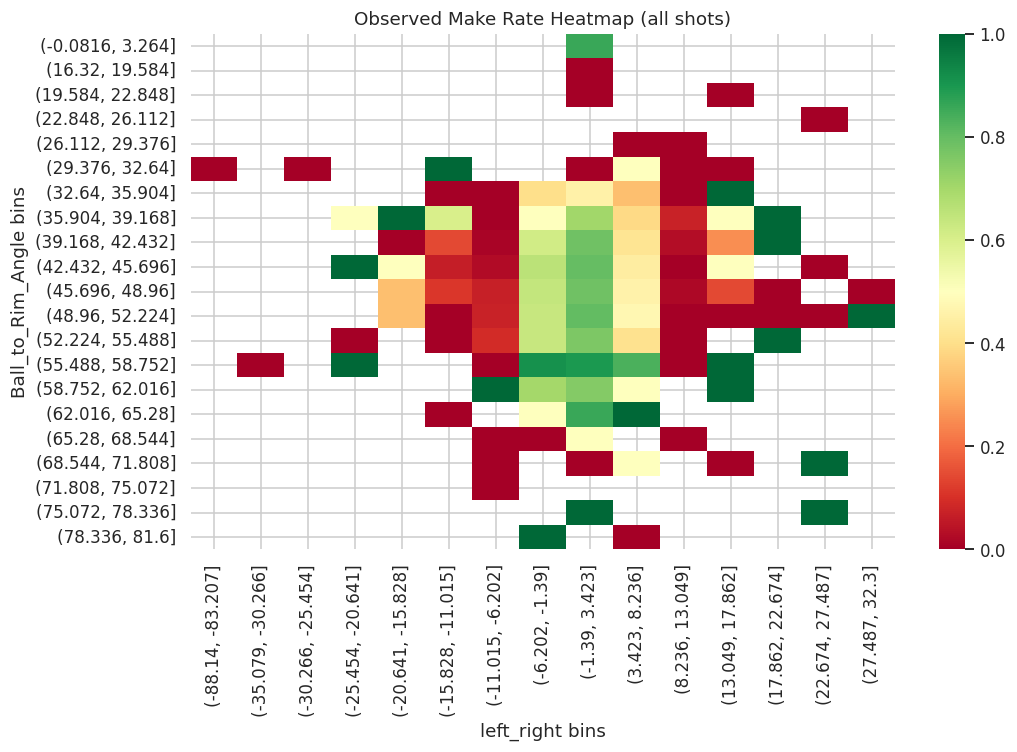

In [4]:
N_BINS = 25
tmp = df_model.copy()
tmp['lr_bin'] = pd.cut(tmp['left_right'], bins=N_BINS)
tmp['bra_bin'] = pd.cut(tmp['Ball_to_Rim_Angle'], bins=N_BINS)

emp = (tmp.groupby(['bra_bin', 'lr_bin'])['Made']
         .mean()
         .unstack())

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(emp, cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_title('Observed Make Rate Heatmap (all shots)')
ax.set_xlabel('left_right bins')
ax.set_ylabel('Ball_to_Rim_Angle bins')
plt.tight_layout()
plt.show()

## Section 5: Model-Based Surface Heatmaps

Surface heatmaps for predicted make probability over:
- x-axis: `left_right`
- y-axis: `Ball_to_Rim_Angle`

Conditioning variables are binned into low/medium/high:
- `Ball_Velocity_per_Distance` (velocity normalized by shot distance)
- `Shot_Distance_to_Rim`
- `Shot_Loc_Angle_to_Rim`

This yields 27 panels (3 angle-level figures; each figure is a 3x3 grid for distance x normalized velocity).

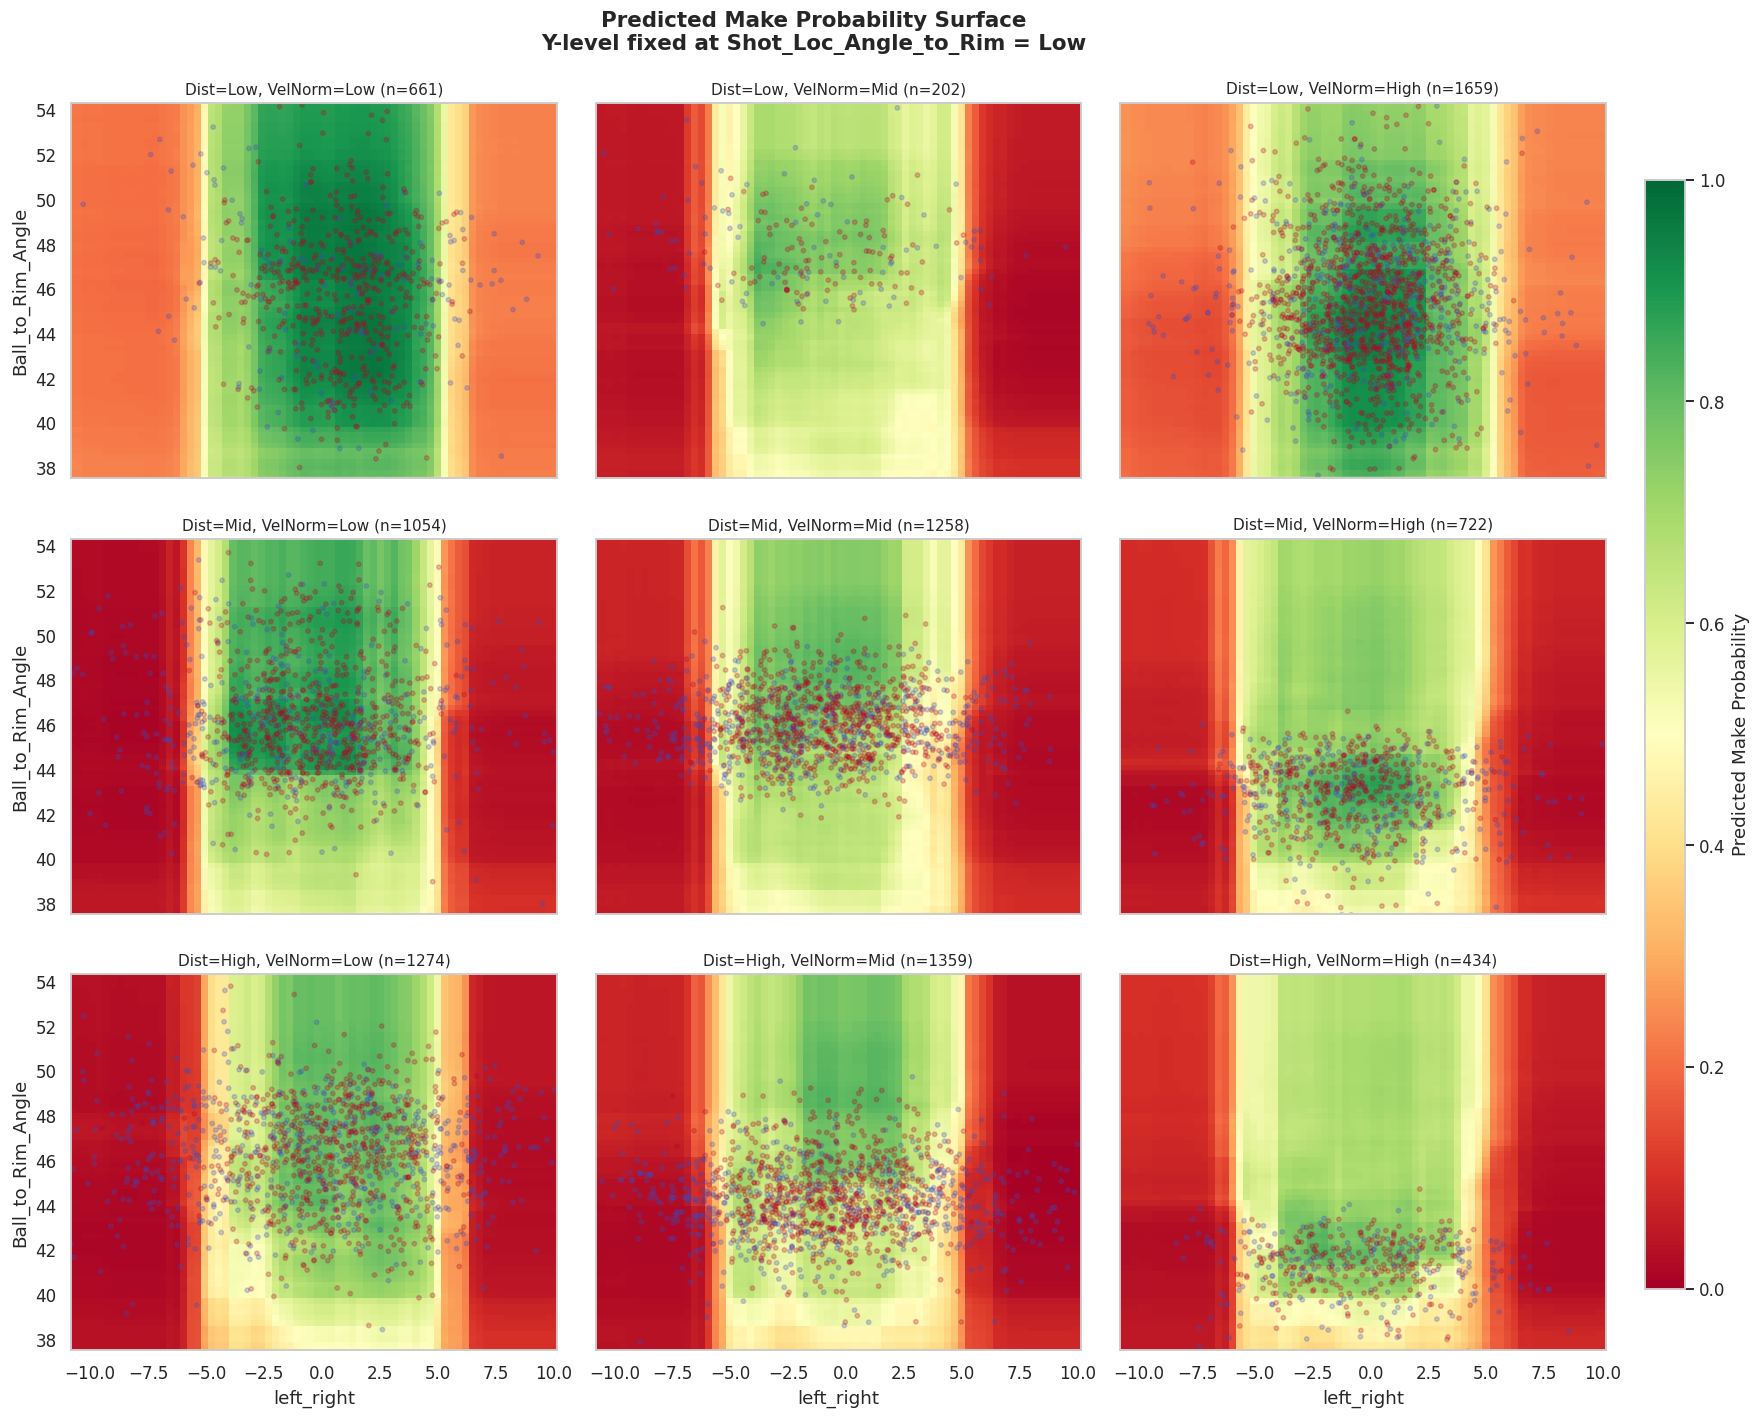

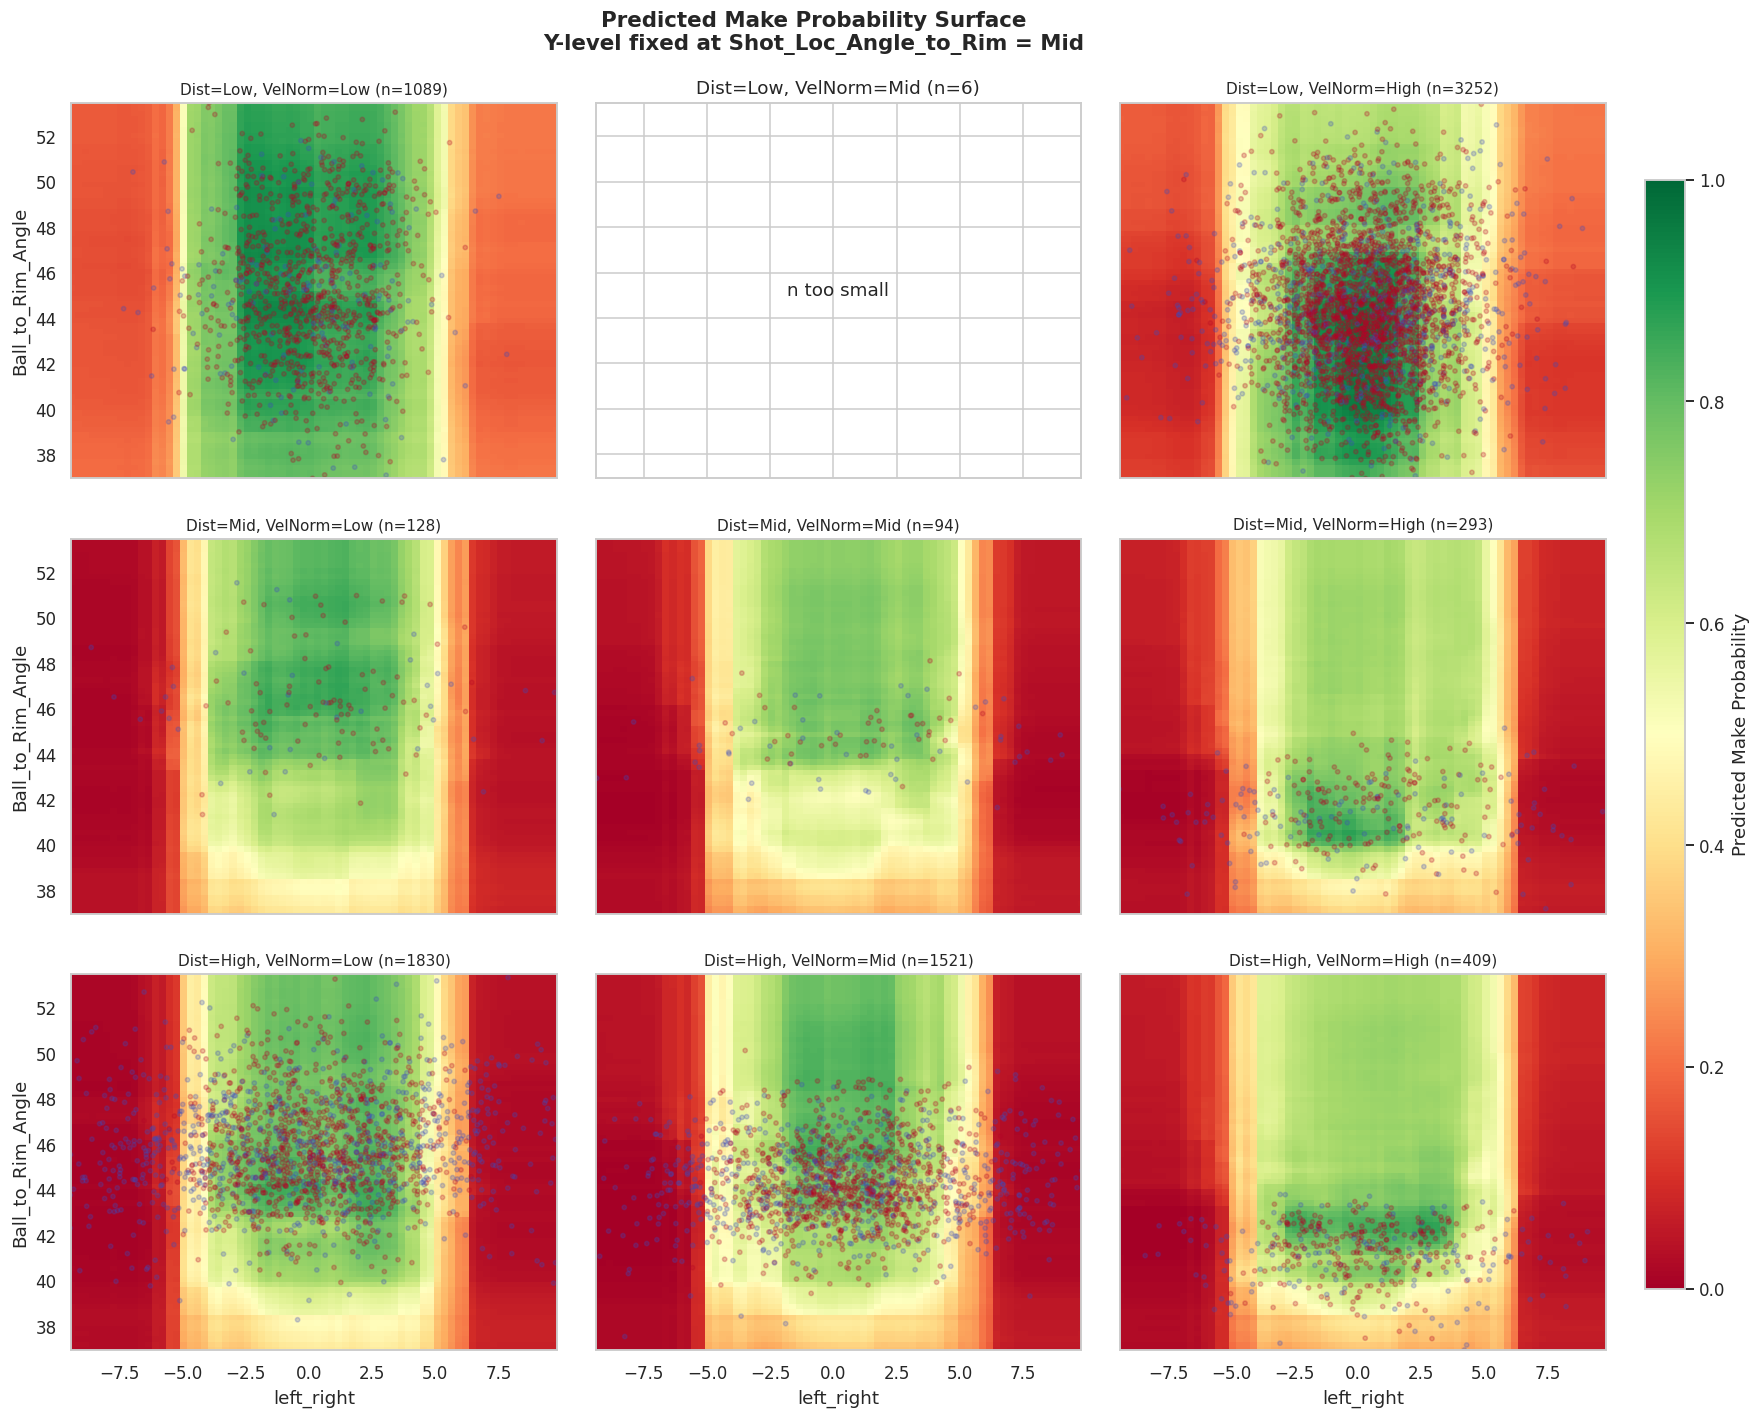

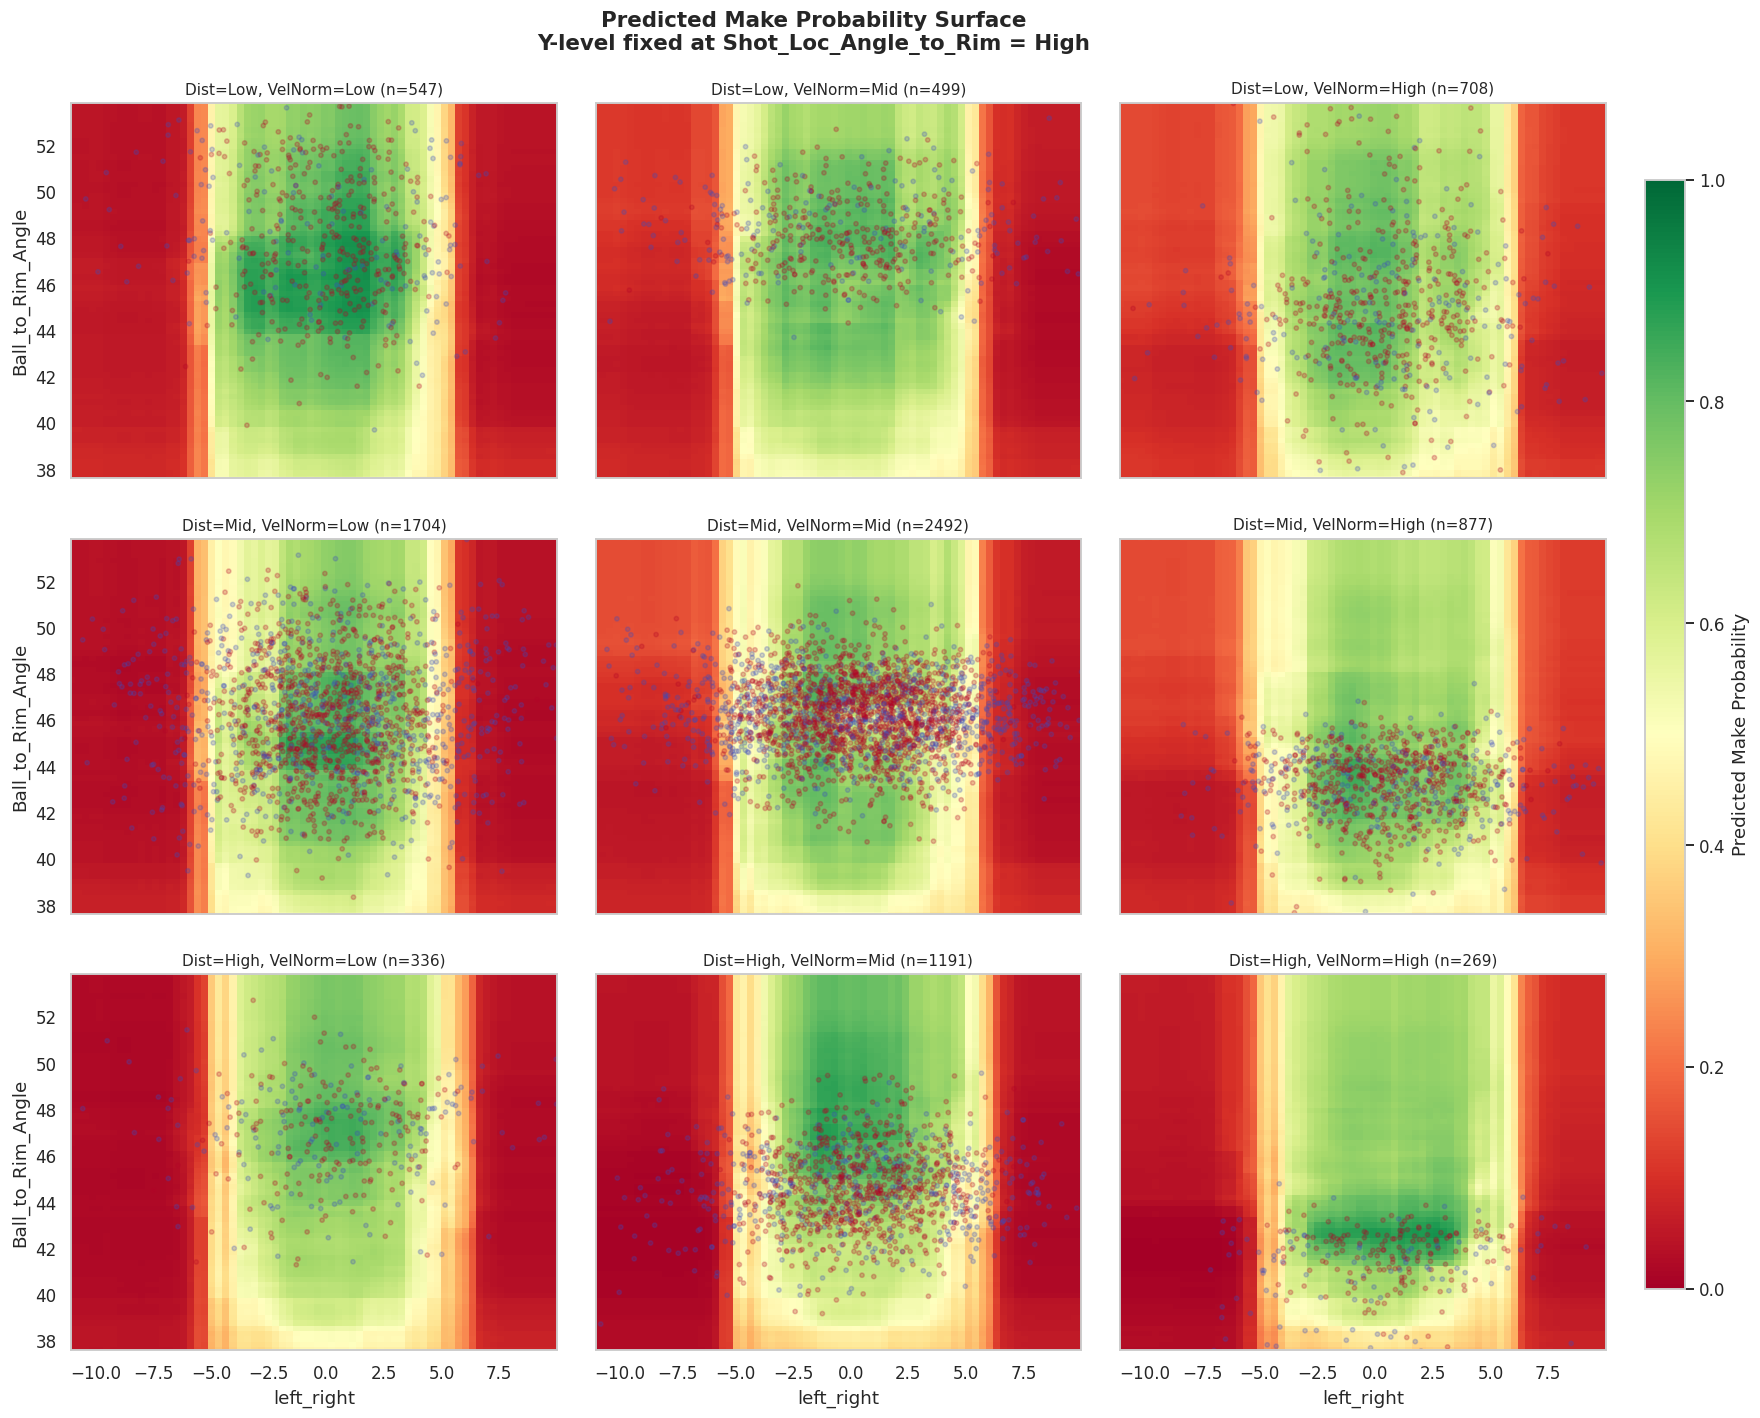

In [5]:
def tercile_cut(series, labels=('Low', 'Mid', 'High')):
    # qcut can fail if too many duplicate values; rank fallback makes bins robust.
    try:
        return pd.qcut(series, q=3, labels=labels, duplicates='drop')
    except ValueError:
        return pd.qcut(series.rank(method='first'), q=3, labels=labels, duplicates='drop')

plot_df = df_model.copy()
plot_df['vel_norm_bin'] = tercile_cut(plot_df['Ball_Velocity_per_Distance'])
plot_df['dist_bin'] = tercile_cut(plot_df['Shot_Distance_to_Rim'])
plot_df['locang_bin'] = tercile_cut(plot_df['Shot_Loc_Angle_to_Rim'])

vel_levels = ['Low', 'Mid', 'High']
dist_levels = ['Low', 'Mid', 'High']
locang_levels = ['Low', 'Mid', 'High']

for locang_level in locang_levels:
    # Tighten ranges to the dense data region for this location-angle slice.
    loc_slice = plot_df[plot_df['locang_bin'].astype(str) == locang_level]
    x_lo, x_hi = loc_slice['left_right'].quantile([0.01, 0.99])
    y_lo, y_hi = loc_slice['Ball_to_Rim_Angle'].quantile([0.01, 0.99])
    x_pad = max((x_hi - x_lo) * 0.06, 0.5)
    y_pad = max((y_hi - y_lo) * 0.06, 0.5)
    x_min, x_max = x_lo - x_pad, x_hi + x_pad
    y_min, y_max = y_lo - y_pad, y_hi + y_pad

    lr_grid = np.linspace(x_min, x_max, 70)
    bra_grid = np.linspace(y_min, y_max, 70)
    xx, yy = np.meshgrid(lr_grid, bra_grid)

    fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=True, sharey=True)
    fig.suptitle(
        'Predicted Make Probability Surface\n'
        + 'Y-level fixed at Shot_Loc_Angle_to_Rim = ' + locang_level,
        fontsize=14, fontweight='bold'
    )
    fig.subplots_adjust(top=0.92, right=0.90, wspace=0.08, hspace=0.16)

    pcm = None
    for i, dist_level in enumerate(dist_levels):
        for j, vel_level in enumerate(vel_levels):
            ax = axes[i, j]
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

            sub = plot_df[
                (plot_df['vel_norm_bin'].astype(str) == vel_level)
                & (plot_df['dist_bin'].astype(str) == dist_level)
                & (plot_df['locang_bin'].astype(str) == locang_level)
            ]

            if len(sub) < 30:
                ax.text(0.5, 0.5, 'n too small', ha='center', va='center', transform=ax.transAxes)
                ax.set_title('Dist=' + dist_level + ', VelNorm=' + vel_level + ' (n=' + str(len(sub)) + ')')
                continue

            cond_vals = {
                'Ball_Velocity_per_Distance': sub['Ball_Velocity_per_Distance'].median(),
                'Shot_Distance_to_Rim': sub['Shot_Distance_to_Rim'].median(),
                'Shot_Loc_Angle_to_Rim': sub['Shot_Loc_Angle_to_Rim'].median(),
            }

            grid_df = pd.DataFrame({
                'Ball_to_Rim_Angle': yy.ravel(),
                'Ball_Velocity_per_Distance': cond_vals['Ball_Velocity_per_Distance'],
                'left_right': xx.ravel(),
                'Shot_Loc_Angle_to_Rim': cond_vals['Shot_Loc_Angle_to_Rim'],
                'Shot_Distance_to_Rim': cond_vals['Shot_Distance_to_Rim'],
            })

            z = clf.predict_proba(grid_df[feature_cols])[:, 1].reshape(xx.shape)

            pcm = ax.pcolormesh(xx, yy, z, cmap='RdYlGn', vmin=0, vmax=1, shading='auto')
            ax.scatter(
                sub['left_right'],
                sub['Ball_to_Rim_Angle'],
                c=sub['Made'],
                cmap='coolwarm',
                s=8,
                alpha=0.25,
                vmin=0,
                vmax=1
            )
            ax.set_title('Dist=' + dist_level + ', VelNorm=' + vel_level + ' (n=' + str(len(sub)) + ')', fontsize=10)

    for ax in axes[-1, :]:
        ax.set_xlabel('left_right')
    for ax in axes[:, 0]:
        ax.set_ylabel('Ball_to_Rim_Angle')

    if pcm is not None:
        # Put the legend in its own axis so it never overlays any panel.
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.72])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label('Predicted Make Probability')

    plt.show()

## Section 6: Optional Export of Modeled Surfaces

In [6]:
# Example export template if you want to store modeled surfaces for downstream analysis.
# Uncomment to use.

# surface_records = []
# for locang_level, dist_level, vel_level in itertools.product(locang_levels, dist_levels, vel_levels):
#     sub = plot_df[(plot_df['vel_bin'].astype(str) == vel_level)
#                   & (plot_df['dist_bin'].astype(str) == dist_level)
#                   & (plot_df['locang_bin'].astype(str) == locang_level)]
#     if len(sub) < 30:
#         continue
#
#     cond_vals = {
#         'Ball_Velocity': sub['Ball_Velocity'].median(),
#         'Shot_Distance_to_Rim': sub['Shot_Distance_to_Rim'].median(),
#         'Shot_Loc_Angle_to_Rim': sub['Shot_Loc_Angle_to_Rim'].median(),
#     }
#
#     grid_df = pd.DataFrame({
#         'Ball_to_Rim_Angle': yy.ravel(),
#         'Ball_Velocity': cond_vals['Ball_Velocity'],
#         'left_right': xx.ravel(),
#         'Shot_Loc_Angle_to_Rim': cond_vals['Shot_Loc_Angle_to_Rim'],
#         'Shot_Distance_to_Rim': cond_vals['Shot_Distance_to_Rim'],
#     })
#     grid_df['p_make'] = clf.predict_proba(grid_df[feature_cols])[:, 1]
#     grid_df['locang_bin'] = locang_level
#     grid_df['dist_bin'] = dist_level
#     grid_df['vel_bin'] = vel_level
#     surface_records.append(grid_df)
#
# surface_df = pd.concat(surface_records, ignore_index=True)
# surface_df.to_csv('ballflight_to_outcome/make_surface_grid_predictions.csv', index=False)
# print('Saved make_surface_grid_predictions.csv with', len(surface_df), 'rows')

In [7]:
# Diagnostic: calibration and high-probability miss rates on held-out test data.
calib = pd.DataFrame({'p_pred': p_test, 'Made': y_test.values})
calib['p_bin'] = pd.cut(calib['p_pred'], bins=np.linspace(0, 1, 11), include_lowest=True)

calib_summary = (
    calib.groupby('p_bin', observed=False)
    .agg(n=('Made', 'size'), pred_mean=('p_pred', 'mean'), obs_make_rate=('Made', 'mean'))
    .reset_index()
    .sort_values('pred_mean')
)

high_bins = calib[calib['p_pred'] >= 0.8]
very_high_bins = calib[calib['p_pred'] >= 0.9]

print('Calibration by predicted-probability bin (test set):')
print(calib_summary.to_string(index=False))
print()
print('For p_pred >= 0.8: n =', len(high_bins), ', observed make rate =', round(high_bins['Made'].mean(), 3))
print('For p_pred >= 0.9: n =', len(very_high_bins), ', observed make rate =', round(very_high_bins['Made'].mean(), 3))

Calibration by predicted-probability bin (test set):
        p_bin    n  pred_mean  obs_make_rate
(-0.001, 0.1]  402   0.041982       0.022388
   (0.1, 0.2]  149   0.145458       0.127517
   (0.2, 0.3]   89   0.248589       0.191011
   (0.3, 0.4]  122   0.354817       0.344262
   (0.4, 0.5]  225   0.457097       0.484444
   (0.5, 0.6]  400   0.555464       0.550000
   (0.6, 0.7]  914   0.656142       0.671772
   (0.7, 0.8] 1409   0.750937       0.761533
   (0.8, 0.9] 1143   0.843787       0.856518
   (0.9, 1.0]  321   0.926657       0.931464

For p_pred >= 0.8: n = 1464 , observed make rate = 0.873
For p_pred >= 0.9: n = 321 , observed make rate = 0.931


## Section 7: Player Catch-and-Shoot Initial Velocity vs Distance

For one player on catch-and-shoot attempts, visualize how initial ball velocity changes with shot distance using:
- Total initial ball velocity
- Horizontal initial ball velocity component
- Vertical initial ball velocity component

Definitions:
- Total: `Initial.Ball.Velocity`
- Horizontal: `Initial.Ball.Velocity * cos(Initial.Ball.Angle)`
- Vertical: `Initial.Ball.Velocity * sin(Initial.Ball.Angle)`

Player: Player 1
Filter: Off the Dribble
Rows: 51
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Initial velocity trends vs distance:
  Total slope      : 0.22063 | corr: 0.9969
  Horizontal slope : 0.17825 | corr: 0.9895
  Vertical slope   : 0.13571 | corr: 0.9836


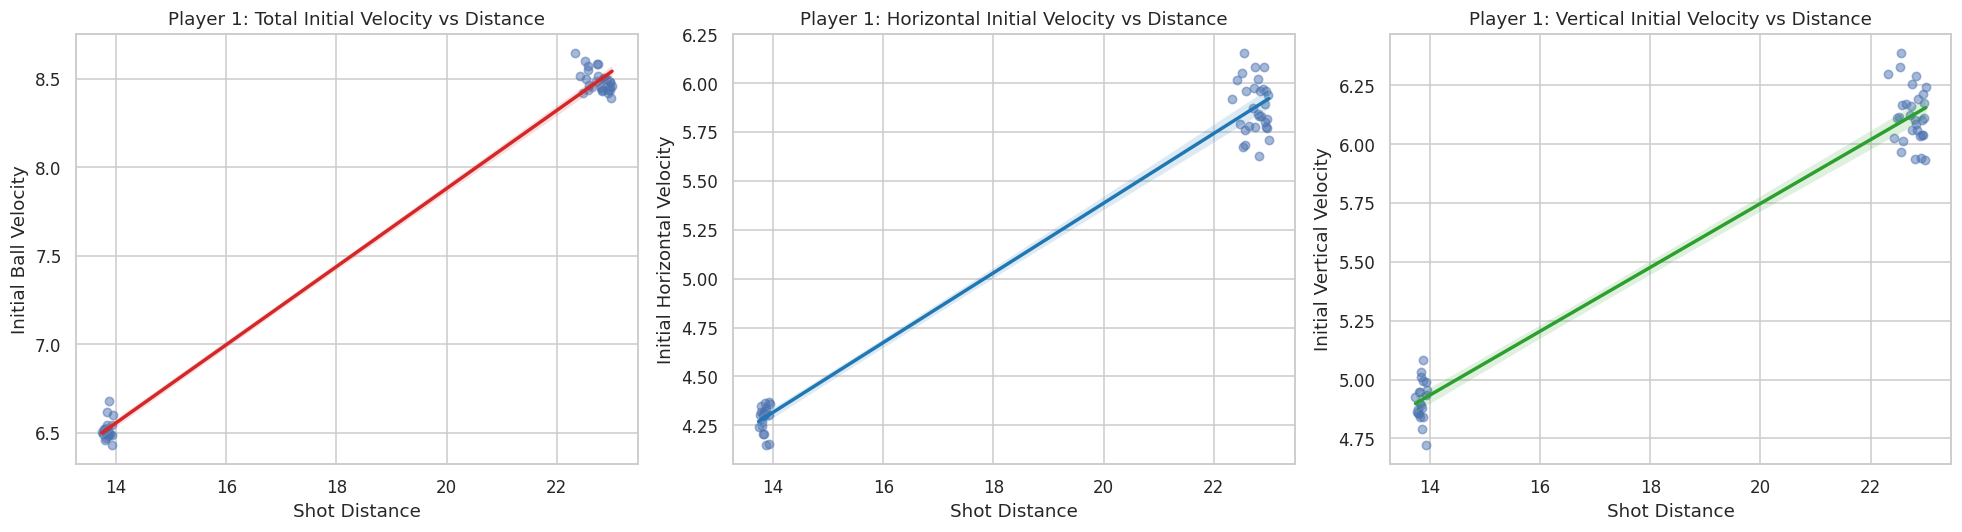

In [ ]:
# -----------------------------
# Player-level catch-and-shoot initial velocity vs distance
# -----------------------------

PLAYER_NAME = 'Player 1'   # Change to any player in the Name column
CATCH_LABEL = 'Catch and Shoot'

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols = [player_col, shot_type_col, dist_col, angle_col, total_vel_col]
if any(c is None for c in required_cols):
    raise ValueError(
        'Missing required columns for this analysis. Found: ' + str(required_cols)
        + '. Required groups: player, shot type, distance, initial angle, initial velocity.'
    )

cs = df[required_cols + ['Made']].copy()
cs = cs[(cs[player_col] == PLAYER_NAME) & (cs[shot_type_col] == CATCH_LABEL)].copy()
cs = cs.dropna(subset=[dist_col, angle_col, total_vel_col])

if len(cs) < 25:
    raise ValueError(
        f'Only {len(cs)} rows found for {PLAYER_NAME} with {CATCH_LABEL}. '
        + 'Choose another player or broaden filter.'
    )

theta = np.deg2rad(cs[angle_col].astype(float))
cs['v_init_total'] = cs[total_vel_col].astype(float)
cs['v_init_horiz'] = cs['v_init_total'] * np.cos(theta)
cs['v_init_vert'] = cs['v_init_total'] * np.sin(theta)

slope_total, _ = np.polyfit(cs[dist_col], cs['v_init_total'], 1)
slope_horiz, _ = np.polyfit(cs[dist_col], cs['v_init_horiz'], 1)
slope_vert, _ = np.polyfit(cs[dist_col], cs['v_init_vert'], 1)

corr_total = cs[[dist_col, 'v_init_total']].corr().iloc[0, 1]
corr_horiz = cs[[dist_col, 'v_init_horiz']].corr().iloc[0, 1]
corr_vert = cs[[dist_col, 'v_init_vert']].corr().iloc[0, 1]

print('Player:', PLAYER_NAME)
print('Filter:', CATCH_LABEL)
print('Rows:', len(cs))
print('Columns used ->',
      'player:', player_col, '| shot_type:', shot_type_col,
      '| distance:', dist_col, '| angle:', angle_col, '| initial_velocity:', total_vel_col)
print()
print('Initial velocity trends vs distance:')
print('  Total slope      :', round(float(slope_total), 5), '| corr:', round(float(corr_total), 4))
print('  Horizontal slope :', round(float(slope_horiz), 5), '| corr:', round(float(corr_horiz), 4))
print('  Vertical slope   :', round(float(slope_vert), 5), '| corr:', round(float(corr_vert), 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    data=cs,
    x=dist_col,
    y='v_init_total',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:red'},
    ax=axes[0],
)
axes[0].set_title(f'{PLAYER_NAME}: Total Initial Velocity vs Distance')
axes[0].set_xlabel('Shot Distance')
axes[0].set_ylabel('Initial Ball Velocity')

sns.regplot(
    data=cs,
    x=dist_col,
    y='v_init_horiz',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:blue'},
    ax=axes[1],
)
axes[1].set_title(f'{PLAYER_NAME}: Horizontal Initial Velocity vs Distance')
axes[1].set_xlabel('Shot Distance')
axes[1].set_ylabel('Initial Horizontal Velocity')

sns.regplot(
    data=cs,
    x=dist_col,
    y='v_init_vert',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:green'},
    ax=axes[2],
)
axes[2].set_title(f'{PLAYER_NAME}: Vertical Initial Velocity vs Distance')
axes[2].set_xlabel('Shot Distance')
axes[2].set_ylabel('Initial Vertical Velocity')

plt.tight_layout()
plt.show()

## Section 8: All-Players Initial Velocity Comparison Table

Build a one-row-per-player comparison for catch-and-shoot attempts, aligned with Section 7 and based on initial velocity only.

Per-player metrics include:
- Sample size and mean distance
- Total initial velocity slope vs distance and correlation
- Horizontal initial velocity slope vs distance and correlation
- Vertical initial velocity slope vs distance and correlation
- Catch-and-shoot make rate

This uses only players with at least `MIN_SHOTS_PER_PLAYER` valid catch-and-shoot attempts.

All-player catch-and-shoot initial-velocity comparison (1 row per player):
Minimum shots per player: 20
Row-level filters -> min initial velocity: 1.0
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Cross-player trend summary:
  corr(total slope, make rate)           = 0.047
  corr(horizontal slope, vertical slope) = -0.2344
  pct players with positive horiz slope  = 100.0 %
  pct players with positive vert slope   = 86.0 %
  DBSCAN outliers (slope-space)          = 12

DBSCAN outlier players:
    player  n_catch_shots  make_rate  horiz_slope_vs_distance  vert_slope_vs_distance
Player 139             76     0.5395                   0.0661                  0.0775
 Player 76             43     0.3488                   0.0664                  0.1219
 Player 52            105     0.6095                   0.0699                  0.0807
 Player 26             43     0.5349                   0

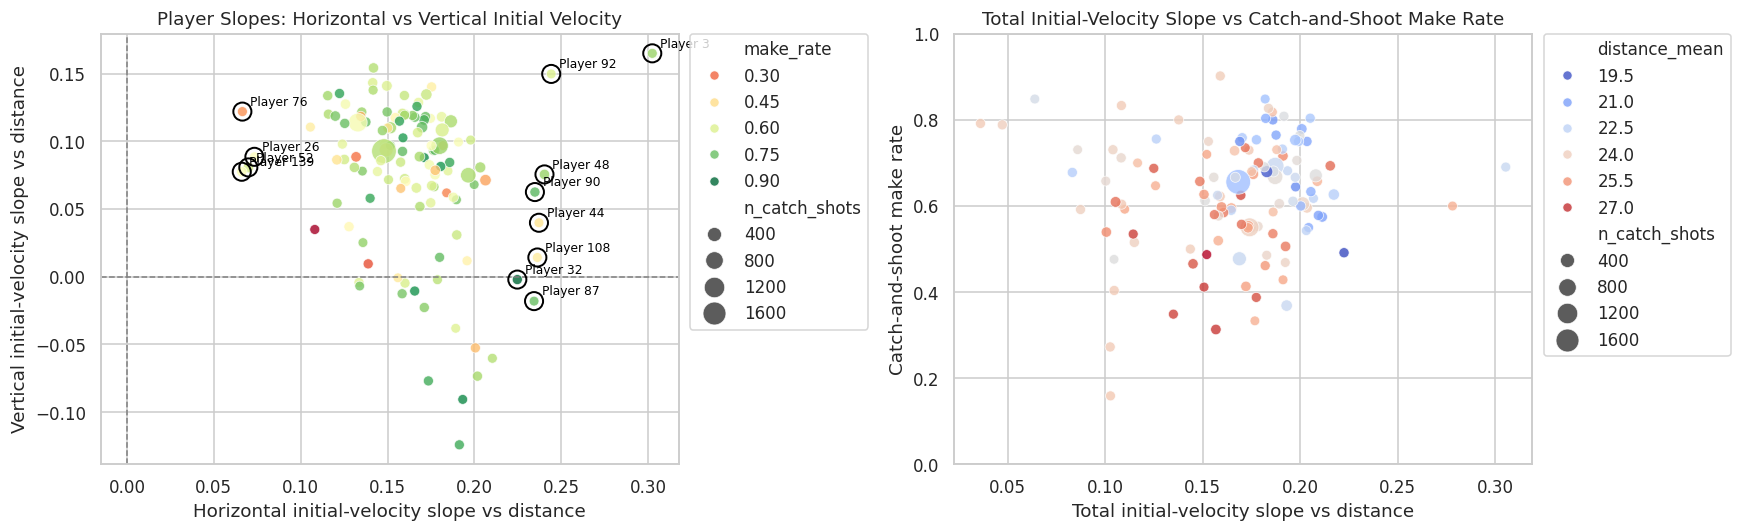

In [19]:
# -----------------------------
# All-players initial velocity comparison (aligned to Section 9)
# -----------------------------

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

MIN_SHOTS_PER_PLAYER = 20
MIN_INIT_SPEED = 1.0
CATCH_LABEL_ALL = 'Catch and Shoot'

# DBSCAN parameters on standardized slope space.
DBSCAN_EPS = 0.75
DBSCAN_MIN_SAMPLES = 5

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col_all = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col_all = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col_all = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col_all = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col_all = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols_all = [
    player_col_all, shot_type_col_all, dist_col_all, angle_col_all, total_vel_col_all, 'Made'
 ]
if any(c is None for c in required_cols_all):
    raise ValueError(
        'Missing required columns for all-player initial-velocity comparison. Found: ' + str(required_cols_all)
    )

cs_all = df[required_cols_all].copy()
cs_all = cs_all[cs_all[shot_type_col_all] == CATCH_LABEL_ALL].copy()
cs_all = cs_all.dropna(subset=[dist_col_all, angle_col_all, total_vel_col_all, player_col_all, 'Made'])
cs_all = cs_all[cs_all[total_vel_col_all].astype(float) >= MIN_INIT_SPEED].copy()

theta_all = np.deg2rad(cs_all[angle_col_all].astype(float))
cs_all['v_init_total'] = cs_all[total_vel_col_all].astype(float)
cs_all['v_init_horiz'] = cs_all['v_init_total'] * np.cos(theta_all)
cs_all['v_init_vert'] = cs_all['v_init_total'] * np.sin(theta_all)

player_rows = []
for player_name, g in cs_all.groupby(player_col_all, observed=False):
    if len(g) < MIN_SHOTS_PER_PLAYER:
        continue

    slope_total, _ = np.polyfit(g[dist_col_all], g['v_init_total'], 1)
    slope_horiz, _ = np.polyfit(g[dist_col_all], g['v_init_horiz'], 1)
    slope_vert, _ = np.polyfit(g[dist_col_all], g['v_init_vert'], 1)

    corr_total = float(g[[dist_col_all, 'v_init_total']].corr().iloc[0, 1])
    corr_horiz = float(g[[dist_col_all, 'v_init_horiz']].corr().iloc[0, 1])
    corr_vert = float(g[[dist_col_all, 'v_init_vert']].corr().iloc[0, 1])

    player_rows.append({
        'player': player_name,
        'n_catch_shots': int(len(g)),
        'distance_mean': float(g[dist_col_all].mean()),
        'total_slope_vs_distance': float(slope_total),
        'total_corr': corr_total,
        'horiz_slope_vs_distance': float(slope_horiz),
        'horiz_corr': corr_horiz,
        'vert_slope_vs_distance': float(slope_vert),
        'vert_corr': corr_vert,
        'make_rate': float(g['Made'].mean()),
    })

player_compare = pd.DataFrame(player_rows)
if player_compare.empty:
    raise ValueError(
        f'No players have at least {MIN_SHOTS_PER_PLAYER} valid catch-and-shoot shots after filters.'
    )

player_compare = player_compare.sort_values(
    ['total_slope_vs_distance', 'horiz_slope_vs_distance', 'n_catch_shots'],
    ascending=[False, False, False]
).reset_index(drop=True)

# DBSCAN on horizontal/vertical slope space.
slope_xy = player_compare[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].values
slope_xy_z = StandardScaler().fit_transform(slope_xy)
db = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
player_compare['dbscan_label'] = db.fit_predict(slope_xy_z)
player_compare['is_dbscan_outlier'] = player_compare['dbscan_label'] == -1

print('All-player catch-and-shoot initial-velocity comparison (1 row per player):')
print('Minimum shots per player:', MIN_SHOTS_PER_PLAYER)
print('Row-level filters -> min initial velocity:', MIN_INIT_SPEED)
print('Columns used ->',
      'player:', player_col_all, '| shot_type:', shot_type_col_all,
      '| distance:', dist_col_all, '| angle:', angle_col_all,
      '| initial_velocity:', total_vel_col_all)
print()

# Compact trend summary to interpret scatter patterns.
corr_total_make = float(player_compare[['total_slope_vs_distance', 'make_rate']].corr().iloc[0, 1])
corr_horiz_vert = float(player_compare[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].corr().iloc[0, 1])
pct_horiz_pos = float((player_compare['horiz_slope_vs_distance'] > 0).mean())
pct_vert_pos = float((player_compare['vert_slope_vs_distance'] > 0).mean())
n_outliers = int(player_compare['is_dbscan_outlier'].sum())

print('Cross-player trend summary:')
print('  corr(total slope, make rate)           =', round(corr_total_make, 4))
print('  corr(horizontal slope, vertical slope) =', round(corr_horiz_vert, 4))
print('  pct players with positive horiz slope  =', round(pct_horiz_pos * 100, 1), '%')
print('  pct players with positive vert slope   =', round(pct_vert_pos * 100, 1), '%')
print('  DBSCAN outliers (slope-space)          =', n_outliers)

if n_outliers > 0:
    print()
    print('DBSCAN outlier players:')
    print(
        player_compare[player_compare['is_dbscan_outlier']][
            ['player', 'n_catch_shots', 'make_rate', 'horiz_slope_vs_distance', 'vert_slope_vs_distance']
        ]
        .sort_values(['horiz_slope_vs_distance', 'vert_slope_vs_distance'])
        .round(4)
        .to_string(index=False)
    )

display_cols = [
    'player', 'n_catch_shots', 'make_rate',
    'total_slope_vs_distance', 'horiz_slope_vs_distance', 'vert_slope_vs_distance',
    'total_corr', 'horiz_corr', 'vert_corr'
 ]

top_n = min(10, len(player_compare))
print()
print('Top players by total_slope_vs_distance:')
print(player_compare[display_cols].head(top_n).round(4).to_string(index=False))

print()
print('Bottom players by total_slope_vs_distance:')
print(player_compare[display_cols].tail(top_n).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=player_compare,
    x='horiz_slope_vs_distance',
    y='vert_slope_vs_distance',
    size='n_catch_shots',
    hue='make_rate',
    palette='RdYlGn',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Player Slopes: Horizontal vs Vertical Initial Velocity')
axes[0].set_xlabel('Horizontal initial-velocity slope vs distance')
axes[0].set_ylabel('Vertical initial-velocity slope vs distance')

# Highlight and label DBSCAN outliers.
outliers = player_compare[player_compare['is_dbscan_outlier']].copy()
if len(outliers) > 0:
    axes[0].scatter(
        outliers['horiz_slope_vs_distance'],
        outliers['vert_slope_vs_distance'],
        s=140,
        facecolors='none',
        edgecolors='black',
        linewidths=1.3,
        zorder=5,
    )
    for _, r in outliers.iterrows():
        axes[0].annotate(
            r['player'],
            (r['horiz_slope_vs_distance'], r['vert_slope_vs_distance']),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=8,
            color='black',
        )
sns.move_legend(axes[0], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

sns.scatterplot(
    data=player_compare,
    x='total_slope_vs_distance',
    y='make_rate',
    size='n_catch_shots',
    hue='distance_mean',
    palette='coolwarm',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Total Initial-Velocity Slope vs Catch-and-Shoot Make Rate')
axes[1].set_xlabel('Total initial-velocity slope vs distance')
axes[1].set_ylabel('Catch-and-shoot make rate')
axes[1].set_ylim(0, 1)
sns.move_legend(axes[1], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

In [20]:
# DBSCAN cluster count summary (from Section 10 results).
if 'player_compare' not in globals() or 'dbscan_label' not in player_compare.columns:
    raise ValueError('Run Section 10 first to populate player_compare with dbscan_label.')

cluster_labels = sorted([c for c in player_compare['dbscan_label'].unique() if c != -1])
n_clusters = len(cluster_labels)
n_outliers = int((player_compare['dbscan_label'] == -1).sum())

print('DBSCAN clusters identified (excluding outliers):', n_clusters)
print('DBSCAN outliers:', n_outliers)

if n_clusters > 0:
    cluster_sizes = (
        player_compare[player_compare['dbscan_label'] != -1]
        .groupby('dbscan_label')
        .size()
        .sort_values(ascending=False)
    )
    print('\nCluster sizes:')
    print(cluster_sizes.to_string())

DBSCAN clusters identified (excluding outliers): 1
DBSCAN outliers: 12

Cluster sizes:
dbscan_label
0    109


DBSCAN tuning table (prioritizing negative-vertical-tail capture):
 eps  min_samples  n_clusters  n_outliers  outlier_rate  neg_tail_outliers  neg_tail_capture_rate
0.55            7           1          32        0.2645                 17                 1.0000
0.50            7           1          34        0.2810                 17                 1.0000
0.45            7           1          35        0.2893                 17                 1.0000
0.55            6           2          24        0.1983                 11                 0.6471
0.50            5           2          28        0.2314                 11                 0.6471
0.50            6           2          28        0.2314                 11                 0.6471
0.45            5           2          29        0.2397                 11                 0.6471
0.45            6           2          29        0.2397                 11                 0.6471
0.60            7           2          22        0.

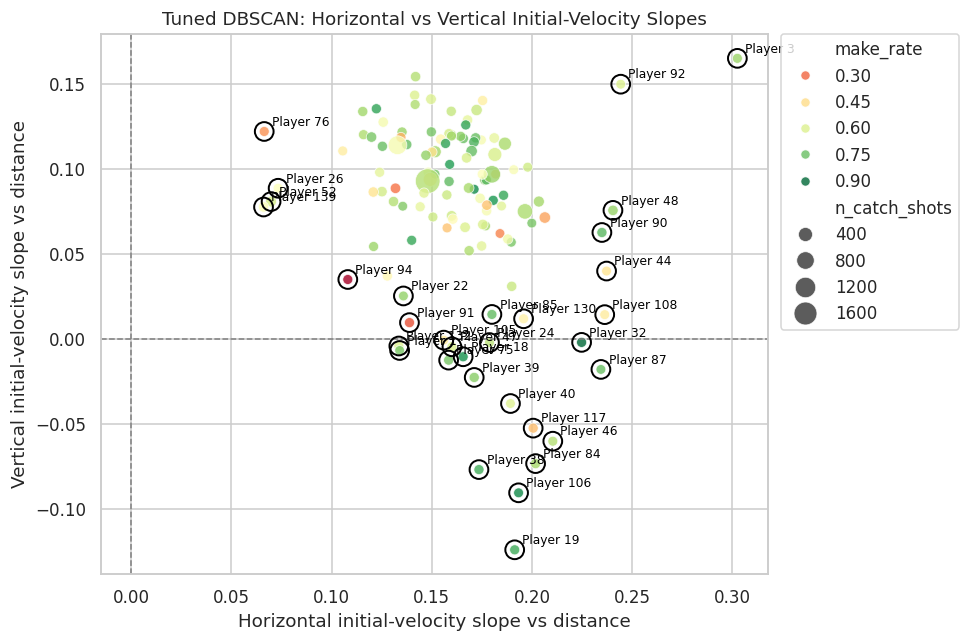

In [21]:
# DBSCAN parameter tuning to better capture the negative-vertical tail as outliers.
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

if 'player_compare' not in globals():
    raise ValueError('Run Section 10 first to build player_compare.')

work = player_compare.copy()
X = work[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].values
Xz = StandardScaler().fit_transform(X)

neg_tail_mask = work['vert_slope_vs_distance'] < 0
n_neg_tail = int(neg_tail_mask.sum())

eps_grid = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
min_samples_grid = [4, 5, 6, 7]

rows = []
for eps in eps_grid:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(Xz)
        outlier_mask = labels == -1
        n_out = int(outlier_mask.sum())
        n_clusters = len(set(labels) - {-1})
        n_neg_tail_out = int((outlier_mask & neg_tail_mask).sum())
        neg_tail_capture = (n_neg_tail_out / n_neg_tail) if n_neg_tail > 0 else np.nan
        outlier_rate = n_out / len(work)
        rows.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'n_outliers': n_out,
            'outlier_rate': outlier_rate,
            'neg_tail_outliers': n_neg_tail_out,
            'neg_tail_capture_rate': neg_tail_capture,
        })

tune = pd.DataFrame(rows).sort_values(
    ['neg_tail_capture_rate', 'n_outliers', 'eps'],
    ascending=[False, True, True]
).reset_index(drop=True)

print('DBSCAN tuning table (prioritizing negative-vertical-tail capture):')
print(tune.round(4).to_string(index=False))

# Pick a balanced candidate: high tail capture, but avoid excessive total outliers.
candidate = tune[(tune['neg_tail_capture_rate'] >= 0.70) & (tune['outlier_rate'] <= 0.35)]
if candidate.empty:
    candidate = tune.head(1)
else:
    candidate = candidate.head(1)

eps_best = float(candidate.iloc[0]['eps'])
ms_best = int(candidate.iloc[0]['min_samples'])
labels_best = DBSCAN(eps=eps_best, min_samples=ms_best).fit_predict(Xz)

work['dbscan_label_tuned'] = labels_best
work['is_dbscan_outlier_tuned'] = work['dbscan_label_tuned'] == -1

print()
print('Selected tuning -> eps =', eps_best, ', min_samples =', ms_best)
print('Clusters (excluding outliers):', len(set(labels_best) - {-1}))
print('Outliers:', int(work['is_dbscan_outlier_tuned'].sum()))
print('Negative-vertical outliers:', int((work['is_dbscan_outlier_tuned'] & neg_tail_mask).sum()), 'of', n_neg_tail)

if work['is_dbscan_outlier_tuned'].any():
    print()
    print('Tuned outlier players:')
    print(
        work[work['is_dbscan_outlier_tuned']][
            ['player', 'n_catch_shots', 'make_rate', 'horiz_slope_vs_distance', 'vert_slope_vs_distance']
        ]
        .sort_values(['vert_slope_vs_distance', 'horiz_slope_vs_distance'])
        .round(4)
        .to_string(index=False)
    )

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=work,
    x='horiz_slope_vs_distance',
    y='vert_slope_vs_distance',
    hue='make_rate',
    size='n_catch_shots',
    palette='RdYlGn',
    sizes=(40, 260),
    alpha=0.8,
 )
plt.axvline(0, linestyle='--', linewidth=1, color='gray')
plt.axhline(0, linestyle='--', linewidth=1, color='gray')
plt.title('Tuned DBSCAN: Horizontal vs Vertical Initial-Velocity Slopes')
plt.xlabel('Horizontal initial-velocity slope vs distance')
plt.ylabel('Vertical initial-velocity slope vs distance')

outliers_tuned = work[work['is_dbscan_outlier_tuned']]
if len(outliers_tuned) > 0:
    plt.scatter(
        outliers_tuned['horiz_slope_vs_distance'],
        outliers_tuned['vert_slope_vs_distance'],
        s=150,
        facecolors='none',
        edgecolors='black',
        linewidths=1.3,
        zorder=6,
    )
    for _, r in outliers_tuned.iterrows():
        plt.annotate(
            r['player'],
            (r['horiz_slope_vs_distance'], r['vert_slope_vs_distance']),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=8,
            color='black',
        )

ax = plt.gca()
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

## Section 9: Player Off-the-Dribble Initial Velocity vs Distance

For one player on off-the-dribble attempts, visualize how initial ball velocity changes with shot distance using:
- Total initial ball velocity
- Horizontal initial ball velocity component
- Vertical initial ball velocity component

Definitions:
- Total: `Initial.Ball.Velocity`
- Horizontal: `Initial.Ball.Velocity * cos(Initial.Ball.Angle)`
- Vertical: `Initial.Ball.Velocity * sin(Initial.Ball.Angle)`

Player: Player 1
Filter: Off the Dribble
Rows: 51
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Initial velocity trends vs distance (Off the Dribble):
  Total slope      : 0.22063 | corr: 0.9969
  Horizontal slope : 0.17825 | corr: 0.9895
  Vertical slope   : 0.13571 | corr: 0.9836


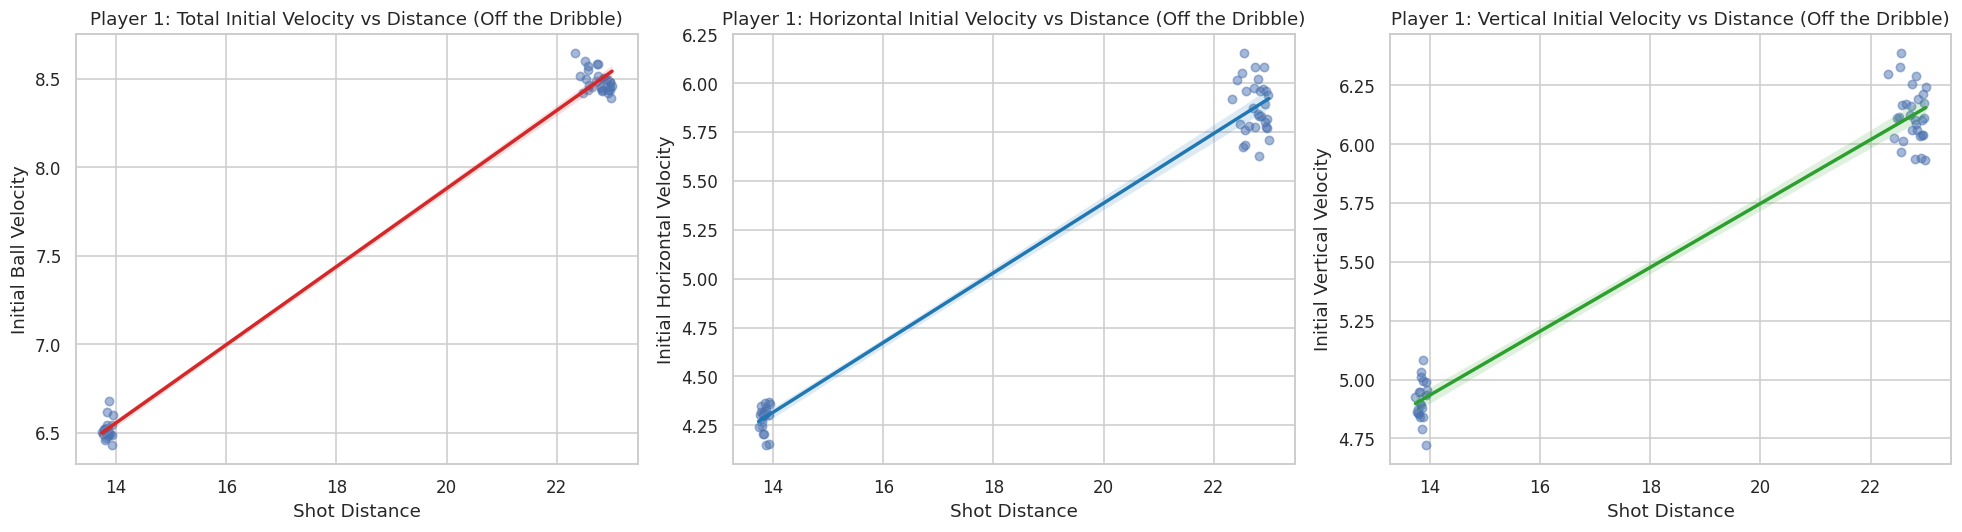

In [26]:
# -----------------------------
# Player-level off-the-dribble initial velocity vs distance
# -----------------------------

PLAYER_NAME_OTD = 'Player 1'   # Change to any player in the Name column
OFF_DRIBBLE_LABEL = 'Off the Dribble'

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols = [player_col, shot_type_col, dist_col, angle_col, total_vel_col]
if any(c is None for c in required_cols):
    raise ValueError(
        'Missing required columns for this analysis. Found: ' + str(required_cols)
        + '. Required groups: player, shot type, distance, initial angle, initial velocity.'
    )

otd = df[required_cols + ['Made']].copy()
otd = otd[(otd[player_col] == PLAYER_NAME_OTD) & (otd[shot_type_col] == OFF_DRIBBLE_LABEL)].copy()
otd = otd.dropna(subset=[dist_col, angle_col, total_vel_col])

if len(otd) < 25:
    raise ValueError(
        f'Only {len(otd)} rows found for {PLAYER_NAME_OTD} with {OFF_DRIBBLE_LABEL}. '
        + 'Choose another player or broaden filter.'
    )

theta = np.deg2rad(otd[angle_col].astype(float))
otd['v_init_total'] = otd[total_vel_col].astype(float)
otd['v_init_horiz'] = otd['v_init_total'] * np.cos(theta)
otd['v_init_vert'] = otd['v_init_total'] * np.sin(theta)

slope_total, _ = np.polyfit(otd[dist_col], otd['v_init_total'], 1)
slope_horiz, _ = np.polyfit(otd[dist_col], otd['v_init_horiz'], 1)
slope_vert, _ = np.polyfit(otd[dist_col], otd['v_init_vert'], 1)

corr_total = otd[[dist_col, 'v_init_total']].corr().iloc[0, 1]
corr_horiz = otd[[dist_col, 'v_init_horiz']].corr().iloc[0, 1]
corr_vert = otd[[dist_col, 'v_init_vert']].corr().iloc[0, 1]

print('Player:', PLAYER_NAME_OTD)
print('Filter:', OFF_DRIBBLE_LABEL)
print('Rows:', len(otd))
print('Columns used ->',
      'player:', player_col, '| shot_type:', shot_type_col,
      '| distance:', dist_col, '| angle:', angle_col, '| initial_velocity:', total_vel_col)
print()
print('Initial velocity trends vs distance (Off the Dribble):')
print('  Total slope      :', round(float(slope_total), 5), '| corr:', round(float(corr_total), 4))
print('  Horizontal slope :', round(float(slope_horiz), 5), '| corr:', round(float(corr_horiz), 4))
print('  Vertical slope   :', round(float(slope_vert), 5), '| corr:', round(float(corr_vert), 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    data=otd,
    x=dist_col,
    y='v_init_total',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:red'},
    ax=axes[0],
)
axes[0].set_title(f'{PLAYER_NAME_OTD}: Total Initial Velocity vs Distance (Off the Dribble)')
axes[0].set_xlabel('Shot Distance')
axes[0].set_ylabel('Initial Ball Velocity')

sns.regplot(
    data=otd,
    x=dist_col,
    y='v_init_horiz',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:blue'},
    ax=axes[1],
)
axes[1].set_title(f'{PLAYER_NAME_OTD}: Horizontal Initial Velocity vs Distance (Off the Dribble)')
axes[1].set_xlabel('Shot Distance')
axes[1].set_ylabel('Initial Horizontal Velocity')

sns.regplot(
    data=otd,
    x=dist_col,
    y='v_init_vert',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:green'},
    ax=axes[2],
)
axes[2].set_title(f'{PLAYER_NAME_OTD}: Vertical Initial Velocity vs Distance (Off the Dribble)')
axes[2].set_xlabel('Shot Distance')
axes[2].set_ylabel('Initial Vertical Velocity')

plt.tight_layout()
plt.show()

## Section 10: All-Players Off-the-Dribble Initial Velocity Comparison Table

Build a one-row-per-player comparison for off-the-dribble attempts, parallel to the catch-and-shoot all-players section.

Per-player metrics include:
- Sample size and mean distance
- Total initial velocity slope vs distance and correlation
- Horizontal initial velocity slope vs distance and correlation
- Vertical initial velocity slope vs distance and correlation
- Off-the-dribble make rate

This uses only players with at least `MIN_SHOTS_PER_PLAYER_OTD` valid off-the-dribble attempts.

All-player off-the-dribble initial-velocity comparison (1 row per player):
Minimum shots per player: 20
Row-level filters -> min initial velocity: 1.0
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Cross-player trend summary:
  corr(total slope, make rate)           = 0.2228
  corr(horizontal slope, vertical slope) = -0.1745
  pct players with positive horiz slope  = 96.4 %
  pct players with positive vert slope   = 96.4 %
  DBSCAN outliers (slope-space)          = 11

DBSCAN outlier players:
    player  n_off_dribble_shots  make_rate  horiz_slope_vs_distance  vert_slope_vs_distance
 Player 44                   29     0.6552                  -0.3781                  0.3303
Player 155                   32     0.7500                  -0.3083                  0.2237
 Player 85                   21     0.7619                  -0.1608                  0.2438
 Player 96                   31 

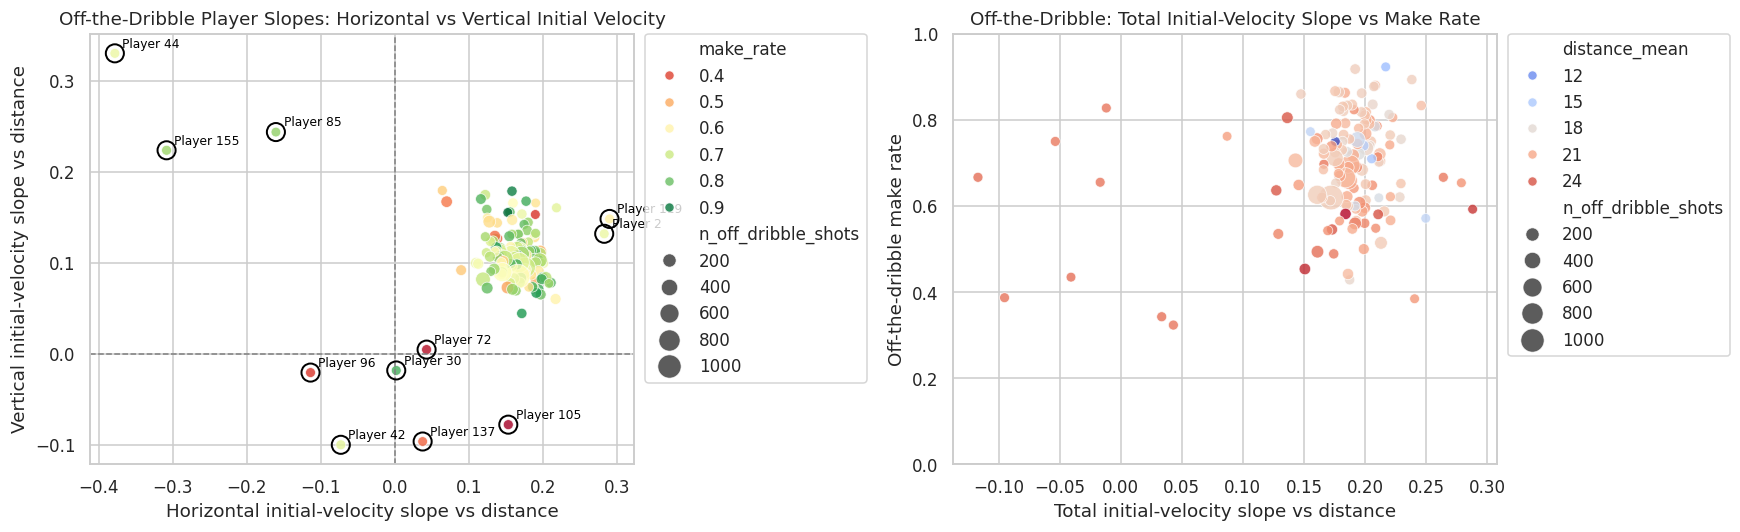

In [27]:
# -----------------------------
# All-players off-the-dribble initial velocity comparison
# -----------------------------

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

MIN_SHOTS_PER_PLAYER_OTD = 20
MIN_INIT_SPEED_OTD = 1.0
OFF_DRIBBLE_LABEL_ALL = 'Off the Dribble'

# DBSCAN parameters on standardized slope space.
DBSCAN_EPS_OTD = 0.75
DBSCAN_MIN_SAMPLES_OTD = 5

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col_otd_all = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col_otd_all = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col_otd_all = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col_otd_all = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col_otd_all = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols_otd_all = [
    player_col_otd_all, shot_type_col_otd_all, dist_col_otd_all, angle_col_otd_all, total_vel_col_otd_all, 'Made'
]
if any(c is None for c in required_cols_otd_all):
    raise ValueError(
        'Missing required columns for all-player off-the-dribble comparison. Found: ' + str(required_cols_otd_all)
    )

otd_all = df[required_cols_otd_all].copy()
otd_all = otd_all[otd_all[shot_type_col_otd_all] == OFF_DRIBBLE_LABEL_ALL].copy()
otd_all = otd_all.dropna(subset=[dist_col_otd_all, angle_col_otd_all, total_vel_col_otd_all, player_col_otd_all, 'Made'])
otd_all = otd_all[otd_all[total_vel_col_otd_all].astype(float) >= MIN_INIT_SPEED_OTD].copy()

theta_otd_all = np.deg2rad(otd_all[angle_col_otd_all].astype(float))
otd_all['v_init_total'] = otd_all[total_vel_col_otd_all].astype(float)
otd_all['v_init_horiz'] = otd_all['v_init_total'] * np.cos(theta_otd_all)
otd_all['v_init_vert'] = otd_all['v_init_total'] * np.sin(theta_otd_all)

player_rows_otd = []
for player_name, g in otd_all.groupby(player_col_otd_all, observed=False):
    if len(g) < MIN_SHOTS_PER_PLAYER_OTD:
        continue

    slope_total, _ = np.polyfit(g[dist_col_otd_all], g['v_init_total'], 1)
    slope_horiz, _ = np.polyfit(g[dist_col_otd_all], g['v_init_horiz'], 1)
    slope_vert, _ = np.polyfit(g[dist_col_otd_all], g['v_init_vert'], 1)

    corr_total = float(g[[dist_col_otd_all, 'v_init_total']].corr().iloc[0, 1])
    corr_horiz = float(g[[dist_col_otd_all, 'v_init_horiz']].corr().iloc[0, 1])
    corr_vert = float(g[[dist_col_otd_all, 'v_init_vert']].corr().iloc[0, 1])

    player_rows_otd.append({
        'player': player_name,
        'n_off_dribble_shots': int(len(g)),
        'distance_mean': float(g[dist_col_otd_all].mean()),
        'total_slope_vs_distance': float(slope_total),
        'total_corr': corr_total,
        'horiz_slope_vs_distance': float(slope_horiz),
        'horiz_corr': corr_horiz,
        'vert_slope_vs_distance': float(slope_vert),
        'vert_corr': corr_vert,
        'make_rate': float(g['Made'].mean()),
    })

player_compare_otd = pd.DataFrame(player_rows_otd)
if player_compare_otd.empty:
    raise ValueError(
        f'No players have at least {MIN_SHOTS_PER_PLAYER_OTD} valid off-the-dribble shots after filters.'
    )

player_compare_otd = player_compare_otd.sort_values(
    ['total_slope_vs_distance', 'horiz_slope_vs_distance', 'n_off_dribble_shots'],
    ascending=[False, False, False]
).reset_index(drop=True)

# DBSCAN on horizontal/vertical slope space.
slope_xy_otd = player_compare_otd[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].values
slope_xy_otd_z = StandardScaler().fit_transform(slope_xy_otd)
db_otd = DBSCAN(eps=DBSCAN_EPS_OTD, min_samples=DBSCAN_MIN_SAMPLES_OTD)
player_compare_otd['dbscan_label'] = db_otd.fit_predict(slope_xy_otd_z)
player_compare_otd['is_dbscan_outlier'] = player_compare_otd['dbscan_label'] == -1

print('All-player off-the-dribble initial-velocity comparison (1 row per player):')
print('Minimum shots per player:', MIN_SHOTS_PER_PLAYER_OTD)
print('Row-level filters -> min initial velocity:', MIN_INIT_SPEED_OTD)
print('Columns used ->',
      'player:', player_col_otd_all, '| shot_type:', shot_type_col_otd_all,
      '| distance:', dist_col_otd_all, '| angle:', angle_col_otd_all,
      '| initial_velocity:', total_vel_col_otd_all)
print()

corr_total_make_otd = float(player_compare_otd[['total_slope_vs_distance', 'make_rate']].corr().iloc[0, 1])
corr_horiz_vert_otd = float(player_compare_otd[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].corr().iloc[0, 1])
pct_horiz_pos_otd = float((player_compare_otd['horiz_slope_vs_distance'] > 0).mean())
pct_vert_pos_otd = float((player_compare_otd['vert_slope_vs_distance'] > 0).mean())
n_outliers_otd = int(player_compare_otd['is_dbscan_outlier'].sum())

print('Cross-player trend summary:')
print('  corr(total slope, make rate)           =', round(corr_total_make_otd, 4))
print('  corr(horizontal slope, vertical slope) =', round(corr_horiz_vert_otd, 4))
print('  pct players with positive horiz slope  =', round(pct_horiz_pos_otd * 100, 1), '%')
print('  pct players with positive vert slope   =', round(pct_vert_pos_otd * 100, 1), '%')
print('  DBSCAN outliers (slope-space)          =', n_outliers_otd)

if n_outliers_otd > 0:
    print()
    print('DBSCAN outlier players:')
    print(
        player_compare_otd[player_compare_otd['is_dbscan_outlier']][
            ['player', 'n_off_dribble_shots', 'make_rate', 'horiz_slope_vs_distance', 'vert_slope_vs_distance']
        ]
        .sort_values(['horiz_slope_vs_distance', 'vert_slope_vs_distance'])
        .round(4)
        .to_string(index=False)
    )

display_cols_otd = [
    'player', 'n_off_dribble_shots', 'make_rate',
    'total_slope_vs_distance', 'horiz_slope_vs_distance', 'vert_slope_vs_distance',
    'total_corr', 'horiz_corr', 'vert_corr'
]

top_n_otd = min(10, len(player_compare_otd))
print()
print('Top players by total_slope_vs_distance:')
print(player_compare_otd[display_cols_otd].head(top_n_otd).round(4).to_string(index=False))

print()
print('Bottom players by total_slope_vs_distance:')
print(player_compare_otd[display_cols_otd].tail(top_n_otd).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=player_compare_otd,
    x='horiz_slope_vs_distance',
    y='vert_slope_vs_distance',
    size='n_off_dribble_shots',
    hue='make_rate',
    palette='RdYlGn',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Off-the-Dribble Player Slopes: Horizontal vs Vertical Initial Velocity')
axes[0].set_xlabel('Horizontal initial-velocity slope vs distance')
axes[0].set_ylabel('Vertical initial-velocity slope vs distance')

outliers_otd = player_compare_otd[player_compare_otd['is_dbscan_outlier']].copy()
if len(outliers_otd) > 0:
    axes[0].scatter(
        outliers_otd['horiz_slope_vs_distance'],
        outliers_otd['vert_slope_vs_distance'],
        s=140,
        facecolors='none',
        edgecolors='black',
        linewidths=1.3,
        zorder=5,
    )
    for _, r in outliers_otd.iterrows():
        axes[0].annotate(
            r['player'],
            (r['horiz_slope_vs_distance'], r['vert_slope_vs_distance']),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=8,
            color='black',
        )
sns.move_legend(axes[0], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

sns.scatterplot(
    data=player_compare_otd,
    x='total_slope_vs_distance',
    y='make_rate',
    size='n_off_dribble_shots',
    hue='distance_mean',
    palette='coolwarm',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Off-the-Dribble: Total Initial-Velocity Slope vs Make Rate')
axes[1].set_xlabel('Total initial-velocity slope vs distance')
axes[1].set_ylabel('Off-the-dribble make rate')
axes[1].set_ylim(0, 1)
sns.move_legend(axes[1], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

## Section 11: Within-Player Movement in Player Slope Space

For each player, map their slope position in 2D space:
- x-axis: horizontal initial-velocity slope vs distance
- y-axis: vertical initial-velocity slope vs distance

Then draw an arrow from the player's catch-and-shoot slope point to their off-the-dribble slope point to show within-player movement in slope space.

Players are included only if they have at least `MIN_SHOTS_PER_TYPE_WITHIN` shots in each shot type.

Within-player slope-space movement summary (Catch and Shoot -> Off the Dribble)
Players meeting threshold: 121
Min shots per type: 15
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Largest movers in player slope space:
    player  n_catch  n_off  horiz_slope_catch  vert_slope_catch  horiz_slope_off  vert_slope_off  delta_horiz_slope  delta_vert_slope  arrow_mag  delta_total_slope  delta_make
 Player 44       32     29             0.2372            0.0398          -0.3781          0.3303            -0.6153            0.2904     0.6804            -0.2093      0.1864
 Player 85       45     21             0.1800            0.0143          -0.1608          0.2438            -0.3408            0.2294     0.4108            -0.0392      0.0063
 Player 19       48     37             0.1914           -0.1241           0.1878          0.1314            -0.0035            0.2555     0.2555       

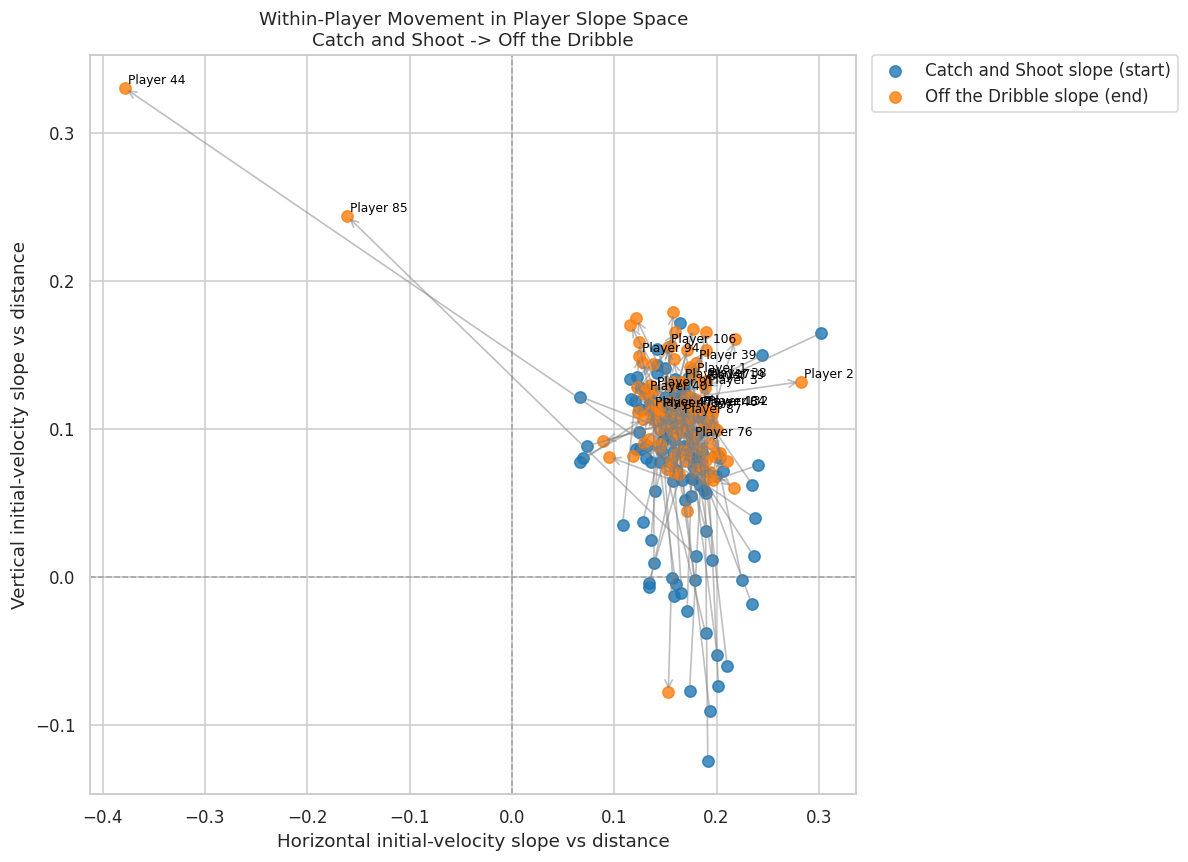

In [30]:
# -----------------------------
# Within-player movement: Catch-and-Shoot -> Off-the-Dribble (slope space)
# -----------------------------

MIN_SHOTS_PER_TYPE_WITHIN = 15
CATCH_LABEL_WITHIN = 'Catch and Shoot'
OFF_LABEL_WITHIN = 'Off the Dribble'
N_LABEL_PLAYERS = 20  # Label the largest movers to keep the figure readable.

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col_within = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col_within = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col_within = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col_within = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col_within = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols_within = [
    player_col_within, shot_type_col_within, dist_col_within, angle_col_within, total_vel_col_within, 'Made'
]
if any(c is None for c in required_cols_within):
    raise ValueError(
        'Missing required columns for within-player slope movement analysis. Found: ' + str(required_cols_within)
    )

within = df[required_cols_within].copy()
within = within[within[shot_type_col_within].isin([CATCH_LABEL_WITHIN, OFF_LABEL_WITHIN])].copy()
within = within.dropna(subset=[player_col_within, dist_col_within, angle_col_within, total_vel_col_within, 'Made'])

theta_within = np.deg2rad(within[angle_col_within].astype(float))
within['v_init_total'] = within[total_vel_col_within].astype(float)
within['v_init_horiz'] = within['v_init_total'] * np.cos(theta_within)
within['v_init_vert'] = within['v_init_total'] * np.sin(theta_within)

rows = []
for (player_name, shot_type), g in within.groupby([player_col_within, shot_type_col_within], observed=False):
    if shot_type not in [CATCH_LABEL_WITHIN, OFF_LABEL_WITHIN]:
        continue
    if len(g) < MIN_SHOTS_PER_TYPE_WITHIN:
        continue
    if float(g[dist_col_within].std()) < 1e-8:
        continue

    slope_h, _ = np.polyfit(g[dist_col_within], g['v_init_horiz'], 1)
    slope_v, _ = np.polyfit(g[dist_col_within], g['v_init_vert'], 1)
    slope_t, _ = np.polyfit(g[dist_col_within], g['v_init_total'], 1)

    rows.append({
        'player': player_name,
        'shot_type': shot_type,
        'n_shots': int(len(g)),
        'horiz_slope': float(slope_h),
        'vert_slope': float(slope_v),
        'total_slope': float(slope_t),
        'mean_distance': float(g[dist_col_within].mean()),
        'make_rate': float(g['Made'].mean()),
    })

slope_df = pd.DataFrame(rows)
if slope_df.empty:
    raise ValueError('No valid player/shot-type groups found after filtering.')

wide = slope_df.pivot(index='player', columns='shot_type')
needed_shot_types = [CATCH_LABEL_WITHIN, OFF_LABEL_WITHIN]
for st in needed_shot_types:
    if st not in wide.columns.get_level_values(1):
        raise ValueError(f'Shot type {st} not present after filtering.')

required_pairs = [
    ('n_shots', CATCH_LABEL_WITHIN), ('n_shots', OFF_LABEL_WITHIN),
    ('horiz_slope', CATCH_LABEL_WITHIN), ('horiz_slope', OFF_LABEL_WITHIN),
    ('vert_slope', CATCH_LABEL_WITHIN), ('vert_slope', OFF_LABEL_WITHIN),
    ('total_slope', CATCH_LABEL_WITHIN), ('total_slope', OFF_LABEL_WITHIN),
]
wide = wide.dropna(subset=required_pairs).copy()
if wide.empty:
    raise ValueError('No players have valid slope points for both shot types.')

move = pd.DataFrame({
    'player': wide.index,
    'n_catch': wide[('n_shots', CATCH_LABEL_WITHIN)].values,
    'n_off': wide[('n_shots', OFF_LABEL_WITHIN)].values,
    'horiz_slope_catch': wide[('horiz_slope', CATCH_LABEL_WITHIN)].values,
    'vert_slope_catch': wide[('vert_slope', CATCH_LABEL_WITHIN)].values,
    'horiz_slope_off': wide[('horiz_slope', OFF_LABEL_WITHIN)].values,
    'vert_slope_off': wide[('vert_slope', OFF_LABEL_WITHIN)].values,
    'total_slope_catch': wide[('total_slope', CATCH_LABEL_WITHIN)].values,
    'total_slope_off': wide[('total_slope', OFF_LABEL_WITHIN)].values,
    'make_catch': wide[('make_rate', CATCH_LABEL_WITHIN)].values,
    'make_off': wide[('make_rate', OFF_LABEL_WITHIN)].values,
    'dist_catch': wide[('mean_distance', CATCH_LABEL_WITHIN)].values,
    'dist_off': wide[('mean_distance', OFF_LABEL_WITHIN)].values,
})

move['n_catch'] = move['n_catch'].astype(int)
move['n_off'] = move['n_off'].astype(int)
move['delta_horiz_slope'] = move['horiz_slope_off'] - move['horiz_slope_catch']
move['delta_vert_slope'] = move['vert_slope_off'] - move['vert_slope_catch']
move['delta_total_slope'] = move['total_slope_off'] - move['total_slope_catch']
move['delta_make'] = move['make_off'] - move['make_catch']
move['arrow_mag'] = np.sqrt(move['delta_horiz_slope'] ** 2 + move['delta_vert_slope'] ** 2)

move = move.sort_values('arrow_mag', ascending=False).reset_index(drop=True)

print('Within-player slope-space movement summary (Catch and Shoot -> Off the Dribble)')
print('Players meeting threshold:', len(move))
print('Min shots per type:', MIN_SHOTS_PER_TYPE_WITHIN)
print('Columns used ->',
      'player:', player_col_within, '| shot_type:', shot_type_col_within,
      '| distance:', dist_col_within, '| angle:', angle_col_within,
      '| initial_velocity:', total_vel_col_within)
print()
print('Largest movers in player slope space:')
show_cols = [
    'player', 'n_catch', 'n_off',
    'horiz_slope_catch', 'vert_slope_catch', 'horiz_slope_off', 'vert_slope_off',
    'delta_horiz_slope', 'delta_vert_slope', 'arrow_mag', 'delta_total_slope', 'delta_make'
]
print(move[show_cols].head(12).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 8))

# Start and end points in slope space.
ax.scatter(
    move['horiz_slope_catch'], move['vert_slope_catch'],
    s=55, c='tab:blue', alpha=0.8, label='Catch and Shoot slope (start)'
)
ax.scatter(
    move['horiz_slope_off'], move['vert_slope_off'],
    s=55, c='tab:orange', alpha=0.8, label='Off the Dribble slope (end)'
)

for _, r in move.iterrows():
    ax.annotate(
        '',
        xy=(r['horiz_slope_off'], r['vert_slope_off']),
        xytext=(r['horiz_slope_catch'], r['vert_slope_catch']),
        arrowprops={'arrowstyle': '->', 'color': 'gray', 'alpha': 0.5, 'lw': 1.1},
    )

to_label = move.head(min(N_LABEL_PLAYERS, len(move)))
for _, r in to_label.iterrows():
    ax.text(
        r['horiz_slope_off'] + 0.003,
        r['vert_slope_off'] + 0.003,
        str(r['player']),
        fontsize=8,
        color='black',
    )

ax.axvline(0, linestyle='--', linewidth=1, color='gray', alpha=0.6)
ax.axhline(0, linestyle='--', linewidth=1, color='gray', alpha=0.6)
ax.set_title('Within-Player Movement in Player Slope Space\nCatch and Shoot -> Off the Dribble')
ax.set_xlabel('Horizontal initial-velocity slope vs distance')
ax.set_ylabel('Vertical initial-velocity slope vs distance')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# Keep this table available for follow-up analysis.
within_player_slope_movement = move.copy()

## Section 12: Cluster Players by Movement Angle and Magnitude

Cluster players using their within-player movement vectors from Section 11, based on:
- Movement angle in slope space
- Movement magnitude

Feature construction:
- `angle_deg`: movement angle from `arctan2(delta_vert_slope, delta_horiz_slope)`
- `mag`: movement magnitude (`arrow_mag`)

The section auto-selects the number of KMeans clusters using silhouette score.

Movement-angle clustering results
Players clustered: 121
Best k by silhouette: 3
Silhouette scores by k:
  k = 2 -> 0.4391
  k = 3 -> 0.488
  k = 4 -> 0.4603
  k = 5 -> 0.4372
  k = 6 -> 0.4129
  k = 7 -> 0.4357
  k = 8 -> 0.4488

Cluster summary:
 movement_cluster  n_players  mean_mag  med_mag  mean_dx  mean_dy  mean_angle_deg
                2          2    0.5456   0.5456  -0.4781   0.2599        150.3911
                1         80    0.0701   0.0521  -0.0016   0.0588         92.2304
                0         39    0.0426   0.0382   0.0056  -0.0224        -71.2549

Sample players per cluster (top 8 by magnitude):

Cluster 0:
    player  n_catch  n_off  angle_deg  delta_horiz_slope  delta_vert_slope  arrow_mag  delta_make
  Player 3       42     60  -162.0891            -0.1142           -0.0369     0.1201     -0.1238
 Player 76       43    119   -14.8757             0.1095           -0.0291     0.1133      0.2730
 Player 92       30     68  -161.3508            -0.1007           -

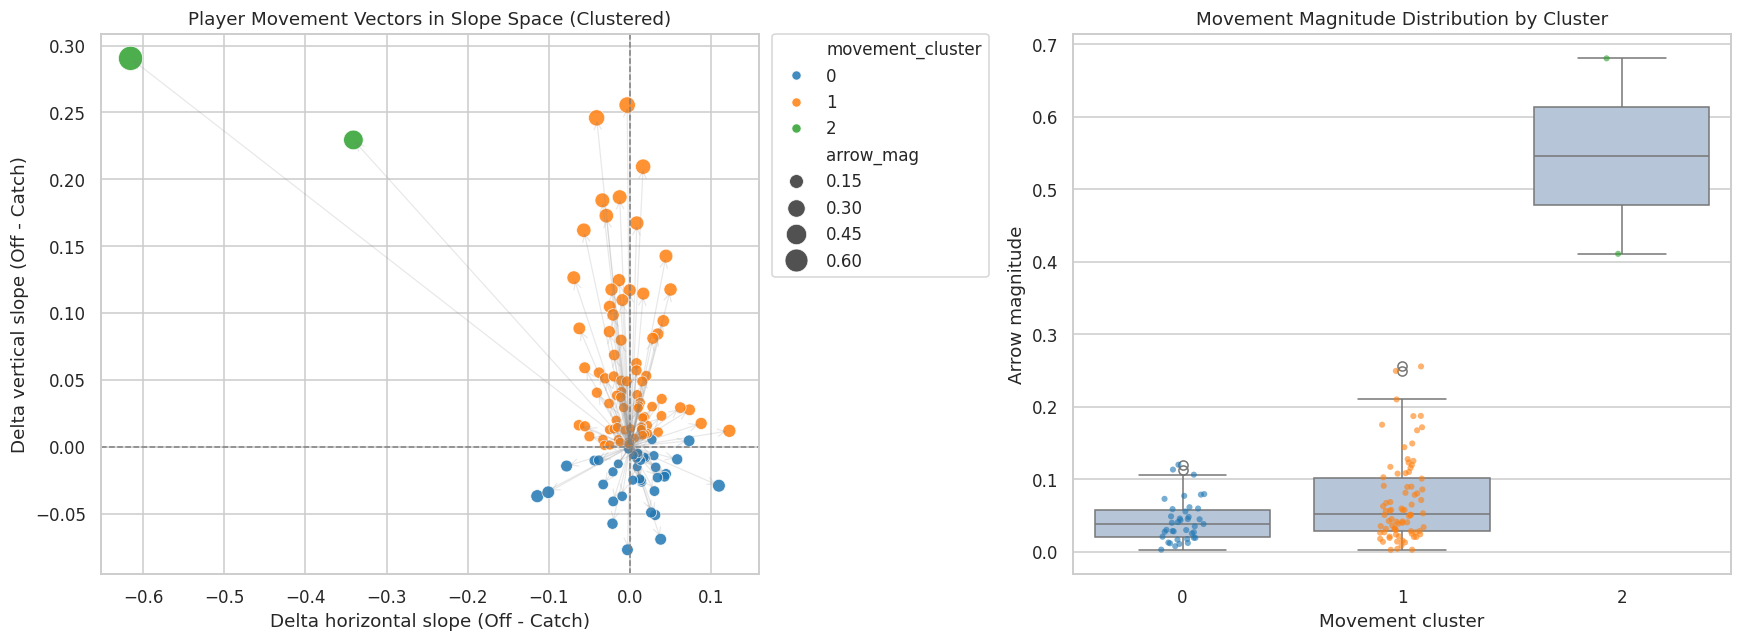

In [32]:
# -----------------------------
# Cluster players by movement angle + magnitude
# -----------------------------

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

if 'within_player_slope_movement' not in globals():
    raise ValueError('Run Section 11 first to create within_player_slope_movement.')

cluster_src = within_player_slope_movement.copy()
if cluster_src.empty:
    raise ValueError('within_player_slope_movement is empty.')

# Movement components in slope space.
dx = cluster_src['delta_horiz_slope'].astype(float).values
dy = cluster_src['delta_vert_slope'].astype(float).values
mag = cluster_src['arrow_mag'].astype(float).values
angle_deg = np.degrees(np.arctan2(dy, dx))

# Feature space uses angle + magnitude directly.
feat = pd.DataFrame({
    'angle_deg': angle_deg,
    'mag': mag,
})

X_feat = StandardScaler().fit_transform(feat[['angle_deg', 'mag']])
n_players = len(feat)

if n_players < 4:
    raise ValueError('Need at least 4 players to run stable clustering.')

k_candidates = list(range(2, min(8, n_players - 1) + 1))
sil_map = {}
for k in k_candidates:
    km_try = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_try = km_try.fit_predict(X_feat)
    sil_map[k] = silhouette_score(X_feat, labels_try)

best_k = max(sil_map, key=sil_map.get)
km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_src['movement_cluster'] = km.fit_predict(X_feat)
cluster_src['angle_deg'] = angle_deg

cluster_summary = (
    cluster_src.groupby('movement_cluster', observed=False)
    .agg(
        n_players=('player', 'size'),
        mean_mag=('arrow_mag', 'mean'),
        med_mag=('arrow_mag', 'median'),
        mean_dx=('delta_horiz_slope', 'mean'),
        mean_dy=('delta_vert_slope', 'mean'),
        mean_angle_deg=('angle_deg', 'mean'),
    )
    .sort_values('mean_mag', ascending=False)
    .reset_index()
 )

print('Movement-angle clustering results')
print('Players clustered:', n_players)
print('Best k by silhouette:', best_k)
print('Silhouette scores by k:')
for k in sorted(sil_map):
    print('  k =', k, '->', round(float(sil_map[k]), 4))
print()
print('Cluster summary:')
print(cluster_summary.round(4).to_string(index=False))

print()
print('Sample players per cluster (top 8 by magnitude):')
for c in sorted(cluster_src['movement_cluster'].unique()):
    sub = cluster_src[cluster_src['movement_cluster'] == c].copy()
    sub = sub.sort_values('arrow_mag', ascending=False)
    print()
    print(f'Cluster {c}:')
    print(
        sub[['player', 'n_catch', 'n_off', 'angle_deg', 'delta_horiz_slope', 'delta_vert_slope', 'arrow_mag', 'delta_make']]
        .head(8)
        .round(4)
        .to_string(index=False)
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=cluster_src,
    x='delta_horiz_slope',
    y='delta_vert_slope',
    hue='movement_cluster',
    size='arrow_mag',
    sizes=(35, 250),
    palette='tab10',
    alpha=0.85,
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Player Movement Vectors in Slope Space (Clustered)')
axes[0].set_xlabel('Delta horizontal slope (Off - Catch)')
axes[0].set_ylabel('Delta vertical slope (Off - Catch)')

for _, r in cluster_src.iterrows():
    axes[0].annotate(
        '',
        xy=(r['delta_horiz_slope'], r['delta_vert_slope']),
        xytext=(0, 0),
        arrowprops={'arrowstyle': '->', 'alpha': 0.18, 'lw': 0.8, 'color': 'gray'},
    )

sns.boxplot(
    data=cluster_src,
    x='movement_cluster',
    y='arrow_mag',
    color='lightsteelblue',
    ax=axes[1],
)
sns.stripplot(
    data=cluster_src,
    x='movement_cluster',
    y='arrow_mag',
    hue='movement_cluster',
    palette='tab10',
    dodge=False,
    alpha=0.6,
    size=4,
    ax=axes[1],
)
axes[1].set_title('Movement Magnitude Distribution by Cluster')
axes[1].set_xlabel('Movement cluster')
axes[1].set_ylabel('Arrow magnitude')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

sns.move_legend(axes[0], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

movement_clustered_players = cluster_src.copy()
movement_cluster_summary = cluster_summary.copy()
movement_cluster_silhouette = sil_map.copy()

## Section 13: General Trend from Catch-and-Shoot to Off-the-Dribble

Summarize the overall cross-player trend in slope-space movement from catch-and-shoot to off-the-dribble.

Key outputs:
- Mean and median shift in horizontal, vertical, and total slope
- Weighted and unweighted trend estimates
- Bootstrap 95% confidence intervals for mean shifts
- Directional breakdown of player movements
- Relationship between slope shift and make-rate shift

General trend summary across players
Players included: 121

Central tendency and uncertainty:
                              metric  mean_unweighted  mean_weighted_by_shots  median  pct_positive  boot95_lo  boot95_hi
Horizontal slope shift (Off - Catch)          -0.0072                 -0.0011  0.0006          51.2    -0.0215     0.0044
  Vertical slope shift (Off - Catch)           0.0359                  0.0149  0.0145          69.4     0.0242     0.0490
     Total slope shift (Off - Catch)           0.0216                  0.0100  0.0155          69.4     0.0119     0.0310
       Make-rate shift (Off - Catch)           0.0730                  0.0582  0.0647          76.9     0.0498     0.0945

Directional breakdown (delta_horiz_slope, delta_vert_slope):
  (+,+): 38 | (-,+): 46 | (-,-): 13 | (+,-): 24

Trend relationships:
  corr(arrow magnitude, make-rate shift) = 0.0621
  corr(total slope shift, make-rate shift) = 0.078

Largest slope-space movers (top 10 by arrow magnitude):
    pl

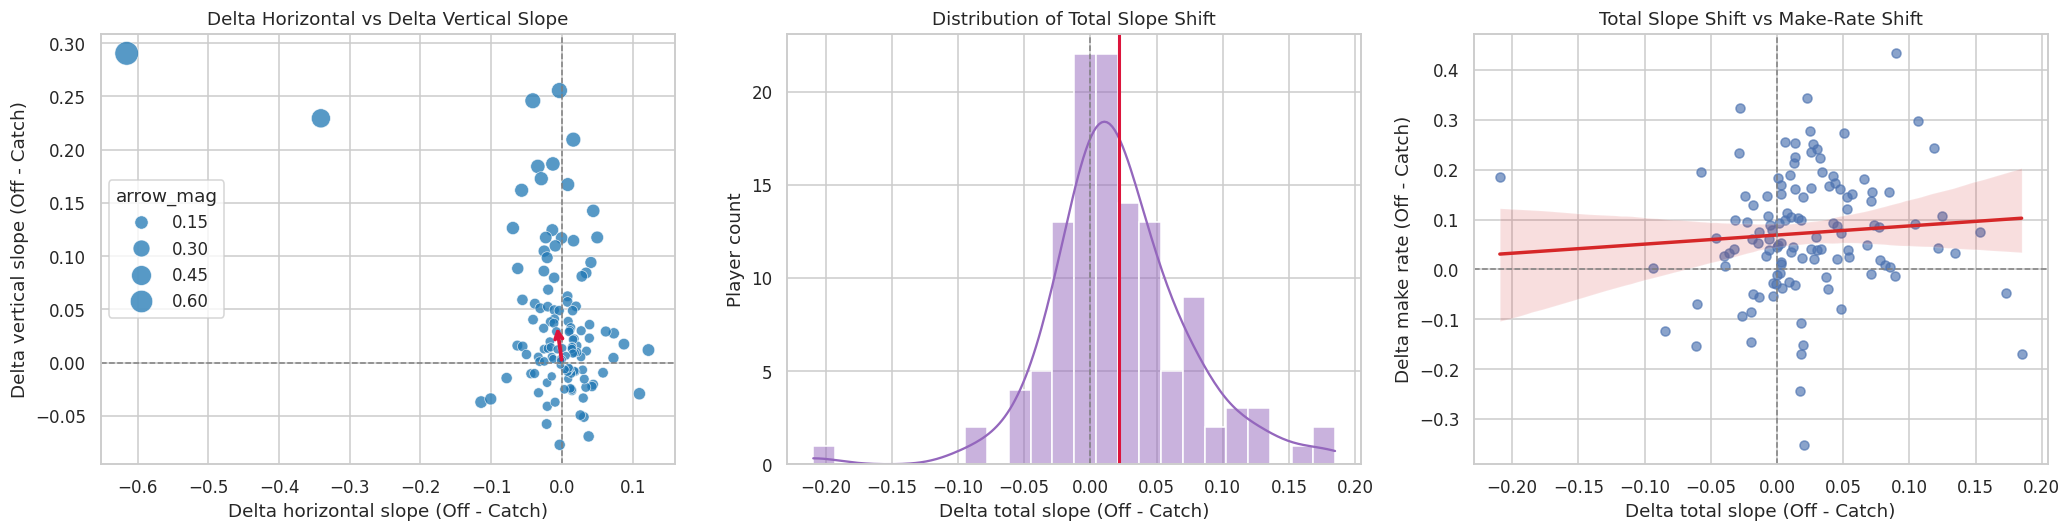

In [33]:
# -----------------------------
# General trend summary: Catch-and-Shoot -> Off-the-Dribble
# -----------------------------

if 'within_player_slope_movement' not in globals():
    raise ValueError('Run Section 11 first to create within_player_slope_movement.')

trend = within_player_slope_movement.copy()
if trend.empty:
    raise ValueError('within_player_slope_movement is empty.')

# Optional shot-volume weights.
trend['w_shots'] = trend['n_catch'].astype(float) + trend['n_off'].astype(float)

def bootstrap_ci_mean(values, n_boot=3000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    vals = np.asarray(values, dtype=float)
    boots = []
    n = len(vals)
    for _ in range(n_boot):
        samp = rng.choice(vals, size=n, replace=True)
        boots.append(np.mean(samp))
    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return float(lo), float(hi)

metrics = [
    ('delta_horiz_slope', 'Horizontal slope shift (Off - Catch)'),
    ('delta_vert_slope', 'Vertical slope shift (Off - Catch)'),
    ('delta_total_slope', 'Total slope shift (Off - Catch)'),
    ('delta_make', 'Make-rate shift (Off - Catch)'),
]

print('General trend summary across players')
print('Players included:', len(trend))
print()

summary_rows = []
for col, label in metrics:
    vals = trend[col].astype(float).values
    mean_u = float(np.mean(vals))
    med = float(np.median(vals))
    mean_w = float(np.average(vals, weights=trend['w_shots']))
    pct_pos = float((vals > 0).mean())
    ci_lo, ci_hi = bootstrap_ci_mean(vals)
    summary_rows.append({
        'metric': label,
        'mean_unweighted': mean_u,
        'mean_weighted_by_shots': mean_w,
        'median': med,
        'pct_positive': pct_pos,
        'boot95_lo': ci_lo,
        'boot95_hi': ci_hi,
    })

trend_summary = pd.DataFrame(summary_rows)
print('Central tendency and uncertainty:')
print(
    trend_summary.assign(
        pct_positive=lambda d: (100 * d['pct_positive']).round(1)
    )
    .round(4)
    .to_string(index=False)
 )

# Directional movement breakdown in slope-space deltas.
q1 = ((trend['delta_horiz_slope'] >= 0) & (trend['delta_vert_slope'] >= 0)).sum()
q2 = ((trend['delta_horiz_slope'] < 0) & (trend['delta_vert_slope'] >= 0)).sum()
q3 = ((trend['delta_horiz_slope'] < 0) & (trend['delta_vert_slope'] < 0)).sum()
q4 = ((trend['delta_horiz_slope'] >= 0) & (trend['delta_vert_slope'] < 0)).sum()

print()
print('Directional breakdown (delta_horiz_slope, delta_vert_slope):')
print('  (+,+):', int(q1), '| (-,+):', int(q2), '| (-,-):', int(q3), '| (+,-):', int(q4))

# Relationship between slope-shift magnitude and make-rate change.
corr_mag_make = float(trend[['arrow_mag', 'delta_make']].corr().iloc[0, 1])
corr_total_make = float(trend[['delta_total_slope', 'delta_make']].corr().iloc[0, 1])
print()
print('Trend relationships:')
print('  corr(arrow magnitude, make-rate shift) =', round(corr_mag_make, 4))
print('  corr(total slope shift, make-rate shift) =', round(corr_total_make, 4))

# Largest directional movers.
print()
print('Largest slope-space movers (top 10 by arrow magnitude):')
print(
    trend[['player', 'n_catch', 'n_off', 'delta_horiz_slope', 'delta_vert_slope', 'delta_total_slope', 'delta_make', 'arrow_mag']]
    .sort_values('arrow_mag', ascending=False)
    .head(10)
    .round(4)
    .to_string(index=False)
 )

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1) Delta horizontal vs delta vertical with mean vector.
sns.scatterplot(
    data=trend,
    x='delta_horiz_slope',
    y='delta_vert_slope',
    size='arrow_mag',
    sizes=(30, 240),
    alpha=0.75,
    color='tab:blue',
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
mean_dx = float(trend['delta_horiz_slope'].mean())
mean_dy = float(trend['delta_vert_slope'].mean())
axes[0].annotate(
    '',
    xy=(mean_dx, mean_dy),
    xytext=(0, 0),
    arrowprops={'arrowstyle': '->', 'color': 'crimson', 'lw': 2.5},
)
axes[0].set_title('Delta Horizontal vs Delta Vertical Slope')
axes[0].set_xlabel('Delta horizontal slope (Off - Catch)')
axes[0].set_ylabel('Delta vertical slope (Off - Catch)')

# 2) Total slope shift distribution.
sns.histplot(trend['delta_total_slope'], bins=24, kde=True, color='tab:purple', ax=axes[1])
axes[1].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[1].axvline(trend['delta_total_slope'].mean(), linestyle='-', linewidth=2, color='crimson')
axes[1].set_title('Distribution of Total Slope Shift')
axes[1].set_xlabel('Delta total slope (Off - Catch)')
axes[1].set_ylabel('Player count')

# 3) Total slope shift vs make-rate shift.
sns.regplot(
    data=trend,
    x='delta_total_slope',
    y='delta_make',
    scatter_kws={'alpha': 0.65, 's': 35},
    line_kws={'color': 'tab:red'},
    ax=axes[2],
)
axes[2].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[2].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[2].set_title('Total Slope Shift vs Make-Rate Shift')
axes[2].set_xlabel('Delta total slope (Off - Catch)')
axes[2].set_ylabel('Delta make rate (Off - Catch)')

plt.tight_layout()
plt.show()

general_trend_summary = trend_summary.copy()

## Section 14: Does Movement Magnitude Relate to Make-Rate Disparity?

Test whether players with larger slope-space movement magnitude (`arrow_mag`) also show larger make-rate differences between catch-and-shoot and off-the-dribble.

This section evaluates association with:
- Signed make-rate difference: `delta_make = make_off - make_catch`
- Absolute make-rate disparity: `abs_delta_make = |delta_make|`

Association between movement (magnitude + direction) and make-rate gap
Players: 121

Magnitude-only relationships:
Signed gap: delta_make = make_off - make_catch
  Pearson corr : 0.0621
  Spearman corr: 0.1335
  OLS slope    : 0.0932 (delta_make per 1.0 arrow_mag)

Absolute disparity: abs_delta_make = |make_off - make_catch|
  Pearson corr : 0.0469
  Spearman corr: 0.0858
  OLS slope    : 0.0504 (abs_delta_make per 1.0 arrow_mag)

Direction-only component correlations (Pearson):
  corr(dir_x, delta_make)      = 0.1155
  corr(dir_y, delta_make)      = 0.0802
  corr(dir_x, abs_delta_make)  = 0.1659
  corr(dir_y, abs_delta_make)  = 0.0564

Combined linear model: target ~ arrow_mag + dir_x + dir_y
  Signed target R^2  = 0.0277
  Coefs [intercept, mag, dir_x, dir_y] = [0.0594, 0.1051, 0.0268, 0.0153]
  Absolute target R^2= 0.0387
  Coefs [intercept, mag, dir_x, dir_y] = [0.1033, 0.0734, 0.0256, 0.0089]

Quartile trend by movement magnitude:
mag_quartile  n_players  mean_arrow_mag  mean_delt

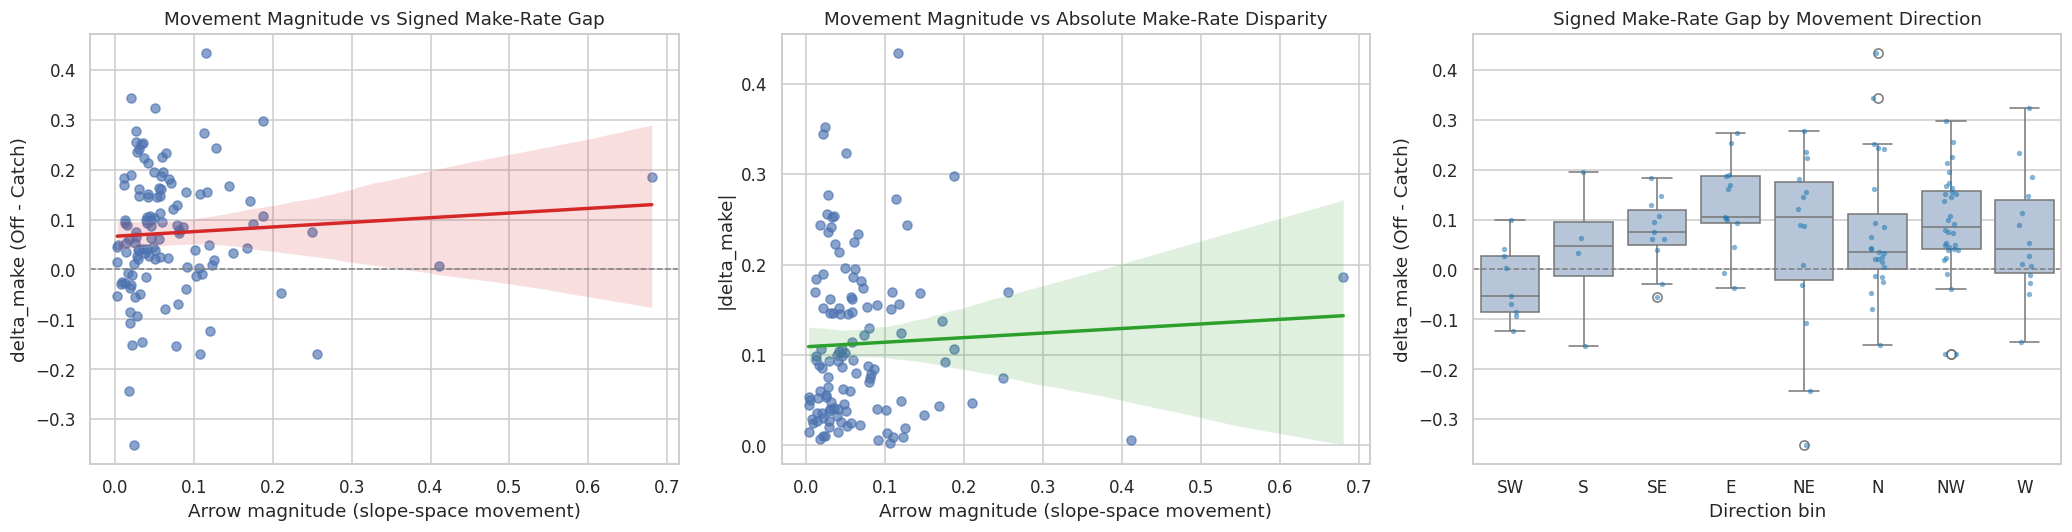

In [36]:
# -----------------------------
# Magnitude + direction vs make-rate disparity
# -----------------------------

if 'within_player_slope_movement' not in globals():
    raise ValueError('Run Section 11 first to create within_player_slope_movement.')

disp = within_player_slope_movement.copy()
if disp.empty:
    raise ValueError('within_player_slope_movement is empty.')

disp['abs_delta_make'] = disp['delta_make'].abs()
disp['angle_deg'] = np.degrees(np.arctan2(disp['delta_vert_slope'], disp['delta_horiz_slope']))
disp['angle_rad'] = np.radians(disp['angle_deg'])
disp['dir_x'] = np.cos(disp['angle_rad'])
disp['dir_y'] = np.sin(disp['angle_rad'])

# Direction bins for interpretability.
dir_edges = [-180, -135, -90, -45, 0, 45, 90, 135, 180]
dir_labels = ['SW', 'S', 'SE', 'E', 'NE', 'N', 'NW', 'W']
disp['direction_bin'] = pd.cut(
    disp['angle_deg'], bins=dir_edges, labels=dir_labels, include_lowest=True
)

pearson_signed = float(disp[['arrow_mag', 'delta_make']].corr(method='pearson').iloc[0, 1])
spearman_signed = float(disp[['arrow_mag', 'delta_make']].corr(method='spearman').iloc[0, 1])
pearson_abs = float(disp[['arrow_mag', 'abs_delta_make']].corr(method='pearson').iloc[0, 1])
spearman_abs = float(disp[['arrow_mag', 'abs_delta_make']].corr(method='spearman').iloc[0, 1])

# Directional component association with make-rate gap.
corr_dirx_signed = float(disp[['dir_x', 'delta_make']].corr(method='pearson').iloc[0, 1])
corr_diry_signed = float(disp[['dir_y', 'delta_make']].corr(method='pearson').iloc[0, 1])
corr_dirx_abs = float(disp[['dir_x', 'abs_delta_make']].corr(method='pearson').iloc[0, 1])
corr_diry_abs = float(disp[['dir_y', 'abs_delta_make']].corr(method='pearson').iloc[0, 1])

# Simple slope estimates for interpretation (magnitude-only).
beta_signed, _ = np.polyfit(disp['arrow_mag'], disp['delta_make'], 1)
beta_abs, _ = np.polyfit(disp['arrow_mag'], disp['abs_delta_make'], 1)

# Multivariate linear fit: target ~ magnitude + direction components.
X = np.column_stack([np.ones(len(disp)), disp['arrow_mag'].values, disp['dir_x'].values, disp['dir_y'].values])
y_signed = disp['delta_make'].values
y_abs = disp['abs_delta_make'].values
coef_signed = np.linalg.lstsq(X, y_signed, rcond=None)[0]
coef_abs = np.linalg.lstsq(X, y_abs, rcond=None)[0]
pred_signed = X @ coef_signed
pred_abs = X @ coef_abs
r2_signed = 1 - np.sum((y_signed - pred_signed) ** 2) / np.sum((y_signed - y_signed.mean()) ** 2)
r2_abs = 1 - np.sum((y_abs - pred_abs) ** 2) / np.sum((y_abs - y_abs.mean()) ** 2)

print('Association between movement (magnitude + direction) and make-rate gap')
print('Players:', len(disp))
print()
print('Magnitude-only relationships:')
print('Signed gap: delta_make = make_off - make_catch')
print('  Pearson corr :', round(pearson_signed, 4))
print('  Spearman corr:', round(spearman_signed, 4))
print('  OLS slope    :', round(float(beta_signed), 4), '(delta_make per 1.0 arrow_mag)')
print()
print('Absolute disparity: abs_delta_make = |make_off - make_catch|')
print('  Pearson corr :', round(pearson_abs, 4))
print('  Spearman corr:', round(spearman_abs, 4))
print('  OLS slope    :', round(float(beta_abs), 4), '(abs_delta_make per 1.0 arrow_mag)')
print()
print('Direction-only component correlations (Pearson):')
print('  corr(dir_x, delta_make)      =', round(corr_dirx_signed, 4))
print('  corr(dir_y, delta_make)      =', round(corr_diry_signed, 4))
print('  corr(dir_x, abs_delta_make)  =', round(corr_dirx_abs, 4))
print('  corr(dir_y, abs_delta_make)  =', round(corr_diry_abs, 4))
print()
print('Combined linear model: target ~ arrow_mag + dir_x + dir_y')
print('  Signed target R^2  =', round(float(r2_signed), 4))
print('  Coefs [intercept, mag, dir_x, dir_y] =', np.round(coef_signed, 4).tolist())
print('  Absolute target R^2=', round(float(r2_abs), 4))
print('  Coefs [intercept, mag, dir_x, dir_y] =', np.round(coef_abs, 4).tolist())

# Quartile trend for an intuitive monotonic check.
disp['mag_quartile'] = pd.qcut(disp['arrow_mag'], q=4, labels=['Q1_small', 'Q2', 'Q3', 'Q4_large'])
quart = (
    disp.groupby('mag_quartile', observed=False)
    .agg(
        n_players=('player', 'size'),
        mean_arrow_mag=('arrow_mag', 'mean'),
        mean_delta_make=('delta_make', 'mean'),
        mean_abs_delta_make=('abs_delta_make', 'mean'),
    )
    .reset_index()
)

# Direction-bin summary.
direction_summary = (
    disp.groupby('direction_bin', observed=False)
    .agg(
        n_players=('player', 'size'),
        mean_arrow_mag=('arrow_mag', 'mean'),
        mean_delta_make=('delta_make', 'mean'),
        mean_abs_delta_make=('abs_delta_make', 'mean'),
    )
    .reset_index()
)

print()
print('Quartile trend by movement magnitude:')
print(quart.round(4).to_string(index=False))
print()
print('Direction-bin trend:')
print(direction_summary.round(4).to_string(index=False))

# Player examples within each bin for interpretation.
EXAMPLES_PER_BIN = 5
example_cols = [
    'player', 'arrow_mag', 'delta_make', 'abs_delta_make',
    'delta_horiz_slope', 'delta_vert_slope', 'angle_deg', 'direction_bin'
]

print()
print(f'Example players by magnitude quartile (top {EXAMPLES_PER_BIN} by abs_delta_make):')
for q in ['Q1_small', 'Q2', 'Q3', 'Q4_large']:
    sub_q = disp[disp['mag_quartile'] == q].copy()
    if sub_q.empty:
        continue
    sub_q = sub_q.sort_values(['abs_delta_make', 'arrow_mag'], ascending=[False, False]).head(EXAMPLES_PER_BIN)
    print()
    print(f'{q}:')
    print(sub_q[example_cols].round(4).to_string(index=False))

print()
print(f'Example players by direction bin (top {EXAMPLES_PER_BIN} by abs_delta_make):')
for d in dir_labels:
    sub_d = disp[disp['direction_bin'] == d].copy()
    if sub_d.empty:
        continue
    sub_d = sub_d.sort_values(['abs_delta_make', 'arrow_mag'], ascending=[False, False]).head(EXAMPLES_PER_BIN)
    print()
    print(f'{d}:')
    print(sub_d[example_cols].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.regplot(
    data=disp,
    x='arrow_mag',
    y='delta_make',
    scatter_kws={'alpha': 0.65, 's': 35},
    line_kws={'color': 'tab:red'},
    ax=axes[0],
)
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Movement Magnitude vs Signed Make-Rate Gap')
axes[0].set_xlabel('Arrow magnitude (slope-space movement)')
axes[0].set_ylabel('delta_make (Off - Catch)')

sns.regplot(
    data=disp,
    x='arrow_mag',
    y='abs_delta_make',
    scatter_kws={'alpha': 0.65, 's': 35},
    line_kws={'color': 'tab:green'},
    ax=axes[1],
)
axes[1].set_title('Movement Magnitude vs Absolute Make-Rate Disparity')
axes[1].set_xlabel('Arrow magnitude (slope-space movement)')
axes[1].set_ylabel('|delta_make|')

sns.boxplot(data=disp, x='direction_bin', y='delta_make', color='lightsteelblue', ax=axes[2])
sns.stripplot(
    data=disp, x='direction_bin', y='delta_make',
    color='tab:blue', alpha=0.55, size=3.5, ax=axes[2]
)
axes[2].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[2].set_title('Signed Make-Rate Gap by Movement Direction')
axes[2].set_xlabel('Direction bin')
axes[2].set_ylabel('delta_make (Off - Catch)')

plt.tight_layout()
plt.show()

magnitude_disparity_stats = {
    'pearson_signed': pearson_signed,
    'spearman_signed': spearman_signed,
    'pearson_abs': pearson_abs,
    'spearman_abs': spearman_abs,
    'slope_signed': float(beta_signed),
    'slope_abs': float(beta_abs),
    'corr_dirx_signed': corr_dirx_signed,
    'corr_diry_signed': corr_diry_signed,
    'corr_dirx_abs': corr_dirx_abs,
    'corr_diry_abs': corr_diry_abs,
    'r2_signed_mag_dir_model': float(r2_signed),
    'r2_abs_mag_dir_model': float(r2_abs),
}
magnitude_disparity_quartiles = quart.copy()
magnitude_disparity_direction_summary = direction_summary.copy()

### Interpreting Direction of Movement in Velocity-Slope Terms

When we talk about **direction of movement**, we are tracking the 2D vector:
- `delta_horiz_slope = horiz_slope_off - horiz_slope_catch`
- `delta_vert_slope = vert_slope_off - vert_slope_catch`

So each player's movement direction describes how their **velocity-vs-distance tuning** changes from Catch-and-Shoot to Off-the-Dribble.

Direction-bin interpretation where bins are defined (with concrete examples):
- `E` (east): higher horizontal slope, little vertical change. Example players in this bin: Player 76, Player 135, Player 127.
- `W` (west): lower horizontal slope, little vertical change. Example players in this bin: Player 161, Player 10, Player 44.
- `N` (north): higher vertical slope, little horizontal change. Example players in this bin: Player 94, Player 101, Player 51.
- `S` (south): lower vertical slope, little horizontal change. Example players in this bin: Player 63, Player 105, Player 20.
- `NE`: both horizontal and vertical slopes increase. Example players in this bin: Player 93, Player 116, Player 115.
- `NW`: horizontal slope decreases while vertical slope increases. Example players in this bin: Player 117, Player 54, Player 53.
- `SE`: horizontal slope increases while vertical slope decreases. Example players in this bin: Player 58, Player 73, Player 49.
- `SW`: both slopes decrease. Example players in this bin: Player 3, Player 48, Player 81.

Basketball interpretation of slope changes:
- Higher horizontal slope means a player's horizontal launch-speed component ramps up more per extra foot of distance.
- Higher vertical slope means a player's vertical launch-speed component ramps up more per extra foot of distance.
- Therefore, direction is a compact summary of *how* a player reallocates velocity components as shot distance grows in Off-the-Dribble compared with Catch-and-Shoot.

How this relates to Section 14 findings:
- Magnitude alone has a weak relationship with make-rate disparity.
- Direction adds some signal, but effect sizes remain modest overall.
- In this dataset, the stronger global trend is positive vertical-slope shift, while horizontal shifts are more mixed across players.

Examples included in Section 14 output:
- For each magnitude quartile (`Q1_small`, `Q2`, `Q3`, `Q4_large`), we show example players (top by absolute make-rate disparity).
- For each direction bin (`SW`, `S`, `SE`, `E`, `NE`, `N`, `NW`, `W`), we also show example players (top by absolute make-rate disparity).
- These examples make it easier to connect the aggregate bin summaries to concrete player-level movement profiles.